# ERM vs Data Augmentation — Domain Adaptation

Binary classification across hospitals.  
Source: $X|Y=y \sim \mathcal{N}(y\mu, \Sigma)$.  
Target: rotation $R_{\theta_e}$ + bias $b_e = s_e \cdot e_2$ on a nuisance direction.

**Notebook structure:**
1. Imports & parameters
2. Helper functions
3. Sanity check — all errors < 0.5
4. Sweep $\lambda$ (regularization)
5. Sweep $\rho$ (rotation augmentation)
6. Sweep $\beta$ — uniform shift
7. Sweep $\theta_e$ — target rotation difficulty (20 runs)
8. Sweep $s_e$ — target bias difficulty (20 runs)
9. Summary: augmentation advantage $\Delta$
10. Sweep $\beta$ — structured shift along $e_2$ vs uniform (20 runs)

## 1. Imports & parameters

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

HERE = pathlib.Path().resolve()
for candidate in [HERE, HERE / 'Empirical-risk-minimization-asymptotics']:
    if (candidate / 'data_models.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import data_models as dm
import losses_regularizers as lr
import erm_theory as et
import data_augmentation as augm

print('✓ Imports OK')

✓ Imports OK


In [2]:
# ── Global parameters ─────────────────────────────────────────────────────
p       = 30
m       = 1.0
sigma   = 1.0
n_train = 50
n_test  = 3000
K_augm  = 10
N_REP   = 20     # repetitions for averaged sweeps

# Fixed target hospital
THETA_E_FIXED = 0.5
S_E_FIXED     = 1

# Default hyperparameters
LAM_DEFAULT  = 0.10
RHO_DEFAULT  = 0.15
BETA_DEFAULT = 0.20

SEED_TRAIN = 0
SEED_TEST  = 1

LOSS_NAMES  = ['Logistic', 'Hinge', 'Squared']
LOSS_COLORS = ['#2077b4', '#d62728', '#2ca02c']

print('✓ Parameters set')

✓ Parameters set


## 2. Helper functions

In [3]:
def e1_vec(p):
    v = np.zeros(p); v[0] = 1.0; return v

def source_model(p, m, sigma):
    C = sigma**2 * np.eye(p); mu = m * e1_vec(p)
    return dm.MultiClassModel(
        components=[dm.GaussianModel(p=p, mu=-mu, C=C),
                    dm.GaussianModel(p=p, mu=+mu, C=C)],
        gamma=[0.5, 0.5], y_values=[-1.0, +1.0])

def target_model(p, m, sigma, theta_e, s_e):
    C = sigma**2 * np.eye(p); mu = m * e1_vec(p)
    R = np.eye(p)
    R[0,0] =  np.cos(theta_e); R[0,1] = -np.sin(theta_e)
    R[1,0] =  np.sin(theta_e); R[1,1] =  np.cos(theta_e)
    b = np.zeros(p); b[1] = s_e
    return dm.MultiClassModel(
        components=[dm.GaussianModel(p=p, mu=R@(-mu)+b, C=C),
                    dm.GaussianModel(p=p, mu=R@(+mu)+b, C=C)],
        gamma=[0.5, 0.5], y_values=[-1.0, +1.0])

def random_rot(p, rng, theta):
    A = rng.standard_normal((p, p)); K = (A - A.T) / 2
    K = K / (np.linalg.norm(K, 'fro') + 1e-15)
    return expm(theta * K)

def make_transform_uniform(p, rho, beta, rng):
    """Rotation + isotropic shift on all coordinates."""
    def transform(X):
        return X @ random_rot(p, rng, rho).T + rng.uniform(-beta, beta, size=p)
    return transform

def make_transform_e2(p, rho, beta, rng):
    """Rotation + shift only along e2 (nuisance direction)."""
    def transform(X):
        s = rng.uniform(-beta, beta)
        eta = np.zeros(p); eta[1] = s
        return X @ random_rot(p, rng, rho).T + eta
    return transform

def make_losses(p):
    return [lr.LogisticLoss(), lr.HingeLoss(), lr.SquaredLoss()]

def make_reg(p, lam):
    return lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

def run_one_rep(mod_src, mod_tgt, losses, lam, rho, beta, seed,
                make_tr=None, n_train=50, n_test=3000, K_augm=10):
    """Train ERM and Augm with same seed, return target errors."""
    if make_tr is None:
        make_tr = make_transform_uniform
    reg = make_reg(p, lam)
    err_erm = []; err_augm = []
    for i, loss in enumerate(losses):
        # ERM
        rng_tr = np.random.default_rng(seed * 100 + i)
        th_erm, _, _ = et.ERMTrainer(model=mod_src, loss=loss,
                                      regularizer=reg).sample_theta_hat(n=n_train, rng=rng_tr)
        rng_te = np.random.default_rng(seed * 100 + i + 50)
        err_erm.append(mod_tgt.error_classif_emp([th_erm], n_test=n_test, rng=rng_te))
        # Augm — same training seed
        rng_tr2 = np.random.default_rng(seed * 100 + i)
        tr = make_tr(p, rho, beta, rng_tr2)
        th_augm, _, _ = augm.DataAugmTrainer(model=mod_src, loss=loss, regularizer=reg,
                                              transform=tr, K_augm=K_augm).sample_theta_hat(
                                              n=n_train, rng=rng_tr2)
        rng_te = np.random.default_rng(seed * 100 + i + 50)
        err_augm.append(mod_tgt.error_classif_emp([th_augm], n_test=n_test, rng=rng_te))
    return err_erm, err_augm

def sweep_param(param_grid, mod_src_fn, mod_tgt_fn, lam_fn, rho_fn, beta_fn,
                N_REP=20, make_tr=None):
    """Generic sweep: for each param value, average over N_REP repetitions."""
    K = 3
    erm_mean  = [[] for _ in range(K)]
    augm_mean = [[] for _ in range(K)]
    erm_std   = [[] for _ in range(K)]
    augm_std  = [[] for _ in range(K)]
    for val in param_grid:
        mod_src = mod_src_fn(val); mod_tgt = mod_tgt_fn(val)
        lam = lam_fn(val); rho = rho_fn(val); beta = beta_fn(val)
        losses = make_losses(p)
        rep_erm  = [[] for _ in range(K)]
        rep_augm = [[] for _ in range(K)]
        for seed in range(N_REP):
            e, a = run_one_rep(mod_src, mod_tgt, losses, lam, rho, beta, seed,
                               make_tr=make_tr)
            for i in range(K):
                rep_erm[i].append(e[i]); rep_augm[i].append(a[i])
        for i in range(K):
            erm_mean[i].append(np.mean(rep_erm[i]))
            augm_mean[i].append(np.mean(rep_augm[i]))
            erm_std[i].append(np.std(rep_erm[i]) / np.sqrt(N_REP))
            augm_std[i].append(np.std(rep_augm[i]) / np.sqrt(N_REP))
    return dict(erm_mean=erm_mean, augm_mean=augm_mean,
                erm_std=erm_std, augm_std=augm_std)

def plot_sweep(res, grid, xlabel, title, suptitle, axes=None, fig=None, show=True):
    if fig is None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(suptitle, fontsize=12, y=1.02)
    for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
        em  = np.array(res['erm_mean'][i]);  es  = np.array(res['erm_std'][i])
        am  = np.array(res['augm_mean'][i]); as_ = np.array(res['augm_std'][i])
        ax.plot(grid, em,  color=col, ls='-',  marker='o', ms=5, label='ERM')
        ax.fill_between(grid, em-es,   em+es,   color=col, alpha=0.15)
        ax.plot(grid, am,  color=col, ls='--', marker='s', ms=5, label='Augmentation')
        ax.fill_between(grid, am-as_,  am+as_,  color=col, alpha=0.15)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(f'{name} loss  —  {title}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        all_v = np.concatenate([em-es, em+es, am-as_, am+as_])
        lo, hi = all_v.min(), all_v.max()
        mg = max((hi - lo) * 0.18, 0.004)
        ax.set_ylim(max(0, lo-mg), min(0.5, hi+mg))
        ax.set_ylabel('Classification error', fontsize=10)
    plt.tight_layout()
    if show: plt.show()
    return fig, axes

# Build fixed models used in most sweeps
MOD_SRC = source_model(p, m, sigma)
MOD_TGT = target_model(p, m, sigma, THETA_E_FIXED, S_E_FIXED)

print('✓ Helper functions defined')

✓ Helper functions defined


## 3. Sanity check — baseline with fixed parameters
Train once, verify all errors < 0.5.

In [4]:
losses = make_losses(p)
errs_erm, errs_augm = run_one_rep(
    MOD_SRC, MOD_TGT, losses,
    lam=LAM_DEFAULT, rho=RHO_DEFAULT, beta=BETA_DEFAULT, seed=SEED_TRAIN)

print(f'Fixed: theta_e={THETA_E_FIXED}, s_e={S_E_FIXED}, '
      f'lambda={LAM_DEFAULT}, rho={RHO_DEFAULT}, beta={BETA_DEFAULT}')
print()
print(f'{"Loss":<12} {"ERM tgt":>9} {"Augm tgt":>10}')
print('-' * 35)
all_errs = []
for i, name in enumerate(LOSS_NAMES):
    row = [errs_erm[i], errs_augm[i]]
    all_errs.extend(row)
    flag = ' ✓' if all(e < 0.5 for e in row) else ' ✗  ← > 0.5!'
    print(f'{name:<12} {row[0]:>9.4f} {row[1]:>10.4f}{flag}')

print()
mx = max(all_errs)
if mx < 0.5:
    print(f'✓ All errors < 0.5 (max = {mx:.4f}). Analysis valid.')
else:
    print(f'✗ Some error >= 0.5 (max = {mx:.4f}). Check parameters!')

Fixed: theta_e=0.5, s_e=1, lambda=0.1, rho=0.15, beta=0.2

Loss           ERM tgt   Augm tgt
-----------------------------------
Logistic        0.3000     0.2980 ✓
Hinge           0.2760     0.2753 ✓
Squared         0.2760     0.2783 ✓

✓ All errors < 0.5 (max = 0.3000). Analysis valid.


## 4. Sweep $\lambda$ — regularization
Fixed: $\theta_e$, $s_e$, $\rho$, $\beta$. Vary $\lambda$. Single run (ERM and Augm re-trained at each $\lambda$).

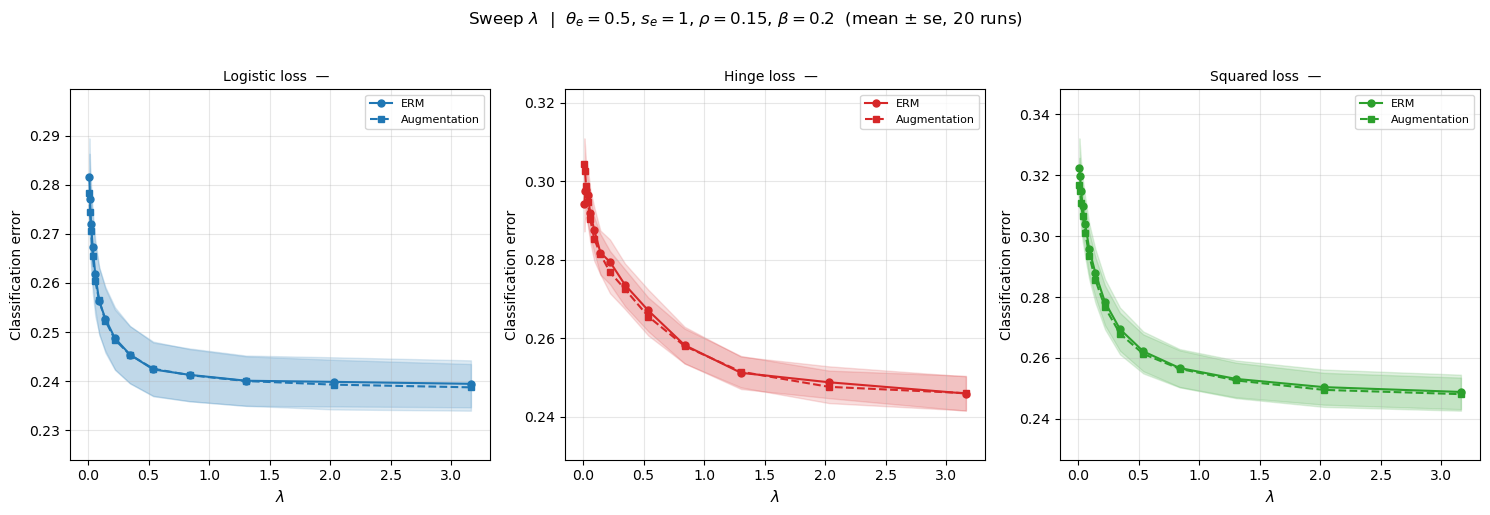

✓ Lambda sweep done


In [5]:
lam_grid = np.logspace(-2, 0.5, 14)

res_lam = sweep_param(
    lam_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: MOD_TGT,
    lam_fn     = lambda v: v,
    rho_fn     = lambda v: RHO_DEFAULT,
    beta_fn    = lambda v: BETA_DEFAULT,
    N_REP      = N_REP,
)

plot_sweep(
    res_lam, lam_grid,
    xlabel  = r'$\lambda$',
    title   = '',
    suptitle= (f'Sweep $\\lambda$  |  $\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
               f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
# log scale for x after plot
print('✓ Lambda sweep done')

## 5. Sweep $\rho$ — rotation augmentation strength
ERM does not depend on $\rho$ — its curve is naturally flat.

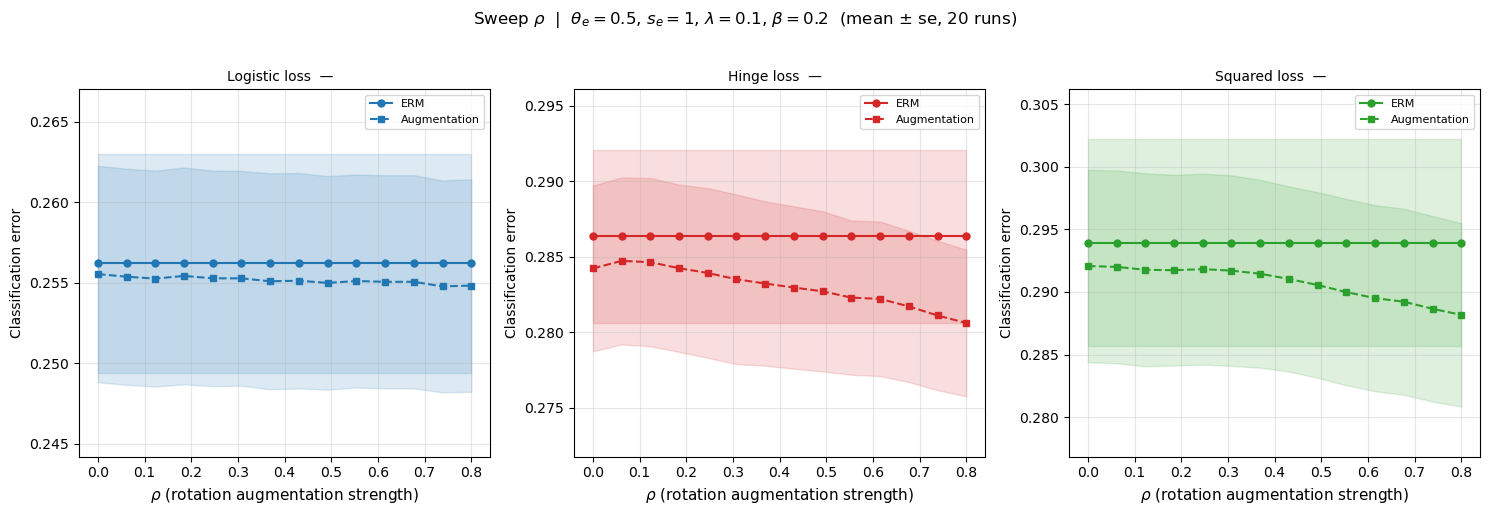

✓ Rho sweep done


In [6]:
rho_grid = np.linspace(0.0, 0.8, 14)

res_rho = sweep_param(
    rho_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: MOD_TGT,
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: v,
    beta_fn    = lambda v: BETA_DEFAULT,
    N_REP      = N_REP,
)

plot_sweep(
    res_rho, rho_grid,
    xlabel  = r'$\rho$ (rotation augmentation strength)',
    title   = '',
    suptitle= (f'Sweep $\\rho$  |  $\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
               f'$\\lambda={LAM_DEFAULT}$, $\\beta={BETA_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
print('✓ Rho sweep done')

## 6. Sweep $\beta$ — uniform shift augmentation
Shift $\eta \sim \mathcal{U}(-\beta,\beta)^p$ applied to all coordinates.

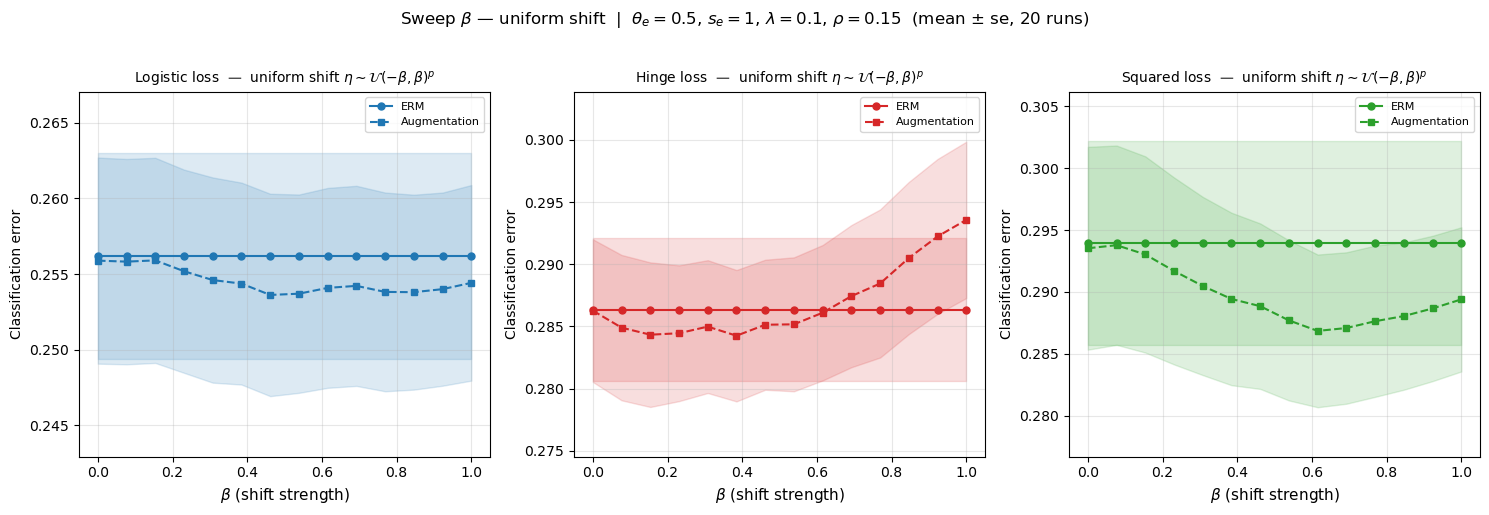

✓ Beta uniform sweep done


In [7]:
beta_grid = np.linspace(0.0, 1.0, 14)

res_beta_uniform = sweep_param(
    beta_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: MOD_TGT,
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: RHO_DEFAULT,
    beta_fn    = lambda v: v,
    N_REP      = N_REP,
    make_tr    = make_transform_uniform,
)

plot_sweep(
    res_beta_uniform, beta_grid,
    xlabel  = r'$\beta$ (shift strength)',
    title   = r'uniform shift $\eta \sim \mathcal{U}(-\beta,\beta)^p$',
    suptitle= (f'Sweep $\\beta$ — uniform shift  |  $\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
               f'$\\lambda={LAM_DEFAULT}$, $\\rho={RHO_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
print('✓ Beta uniform sweep done')

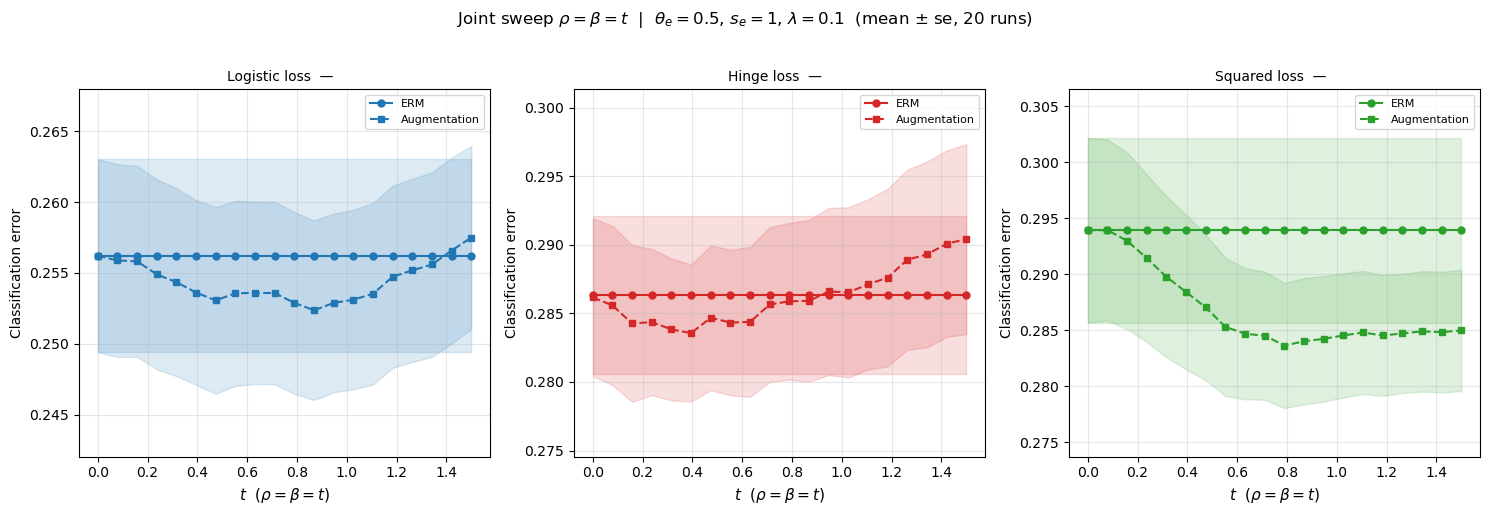

✓ Joint sweep done


In [8]:
t_grid = np.linspace(0., 1.5, 20)

res_joint = sweep_param(
    t_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: MOD_TGT,
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: v,
    beta_fn    = lambda v: v,
    N_REP      = N_REP,
    make_tr    = make_transform_uniform,
)

plot_sweep(
    res_joint, t_grid,
    xlabel  = r'$t$  ($\rho = \beta = t$)',
    title   = '',
    suptitle= (f'Joint sweep $\\rho = \\beta = t$  |  '
               f'$\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
               f'$\\lambda={LAM_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
print('✓ Joint sweep done')

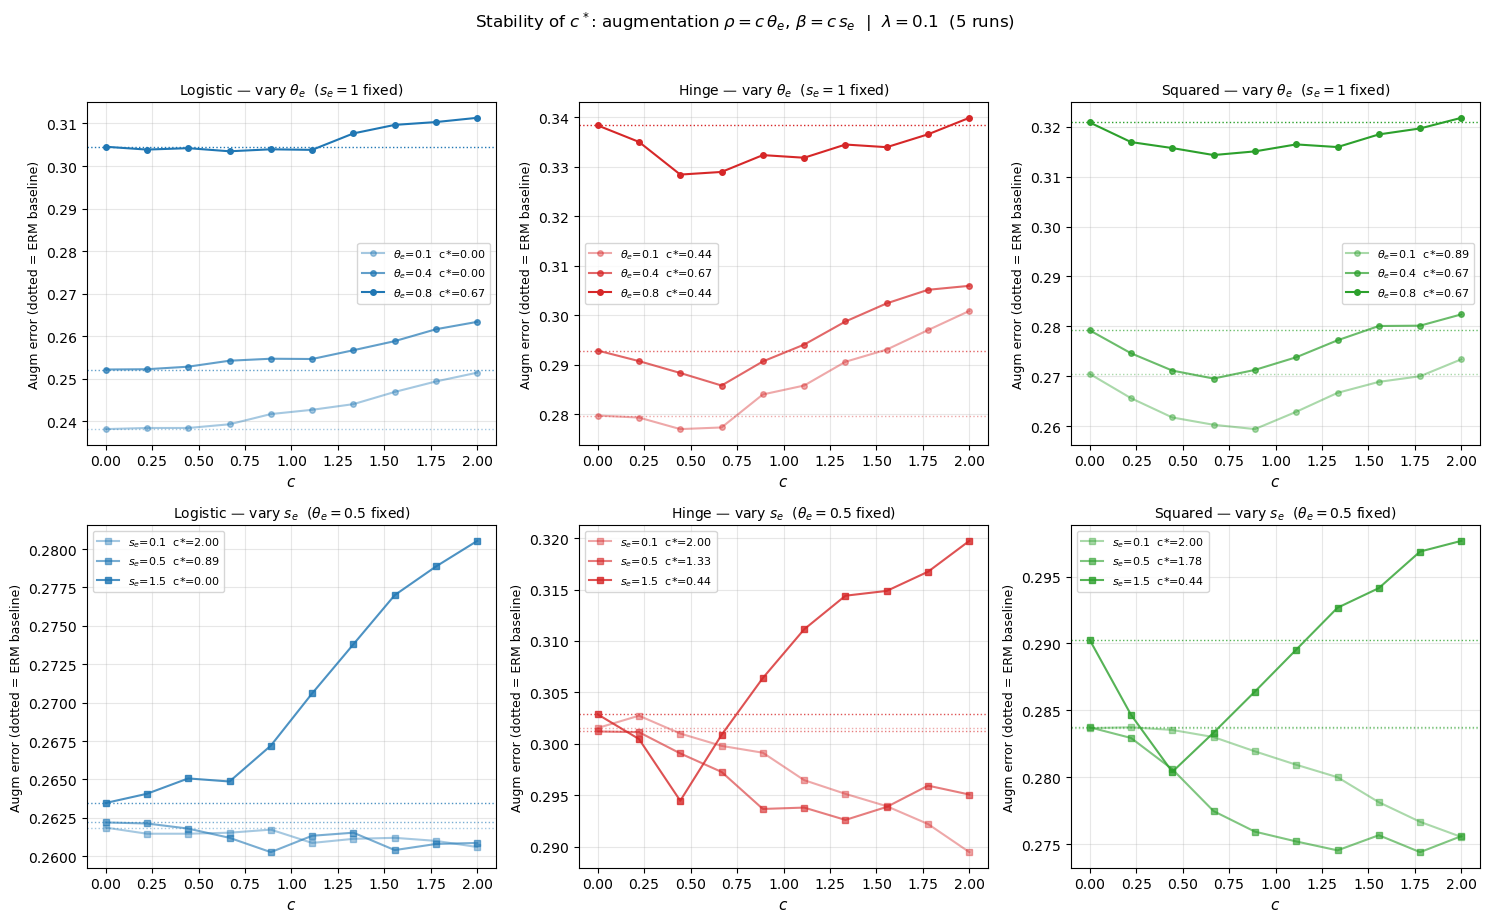

✓ Stability sweep done


In [30]:
N_REP_STAB   = 5
c_grid_stab  = np.linspace(0., 2.0, 10)
theta_e_vals = [0.1, 0.4, 0.8]
s_e_vals     = [0.1, 0.5, 1.5]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    r'Stability of $c^*$: augmentation $\rho = c\,\theta_e$, $\beta = c\,s_e$  |  '
    f'$\\lambda={LAM_DEFAULT}$  ({N_REP_STAB} runs)',
    fontsize=12, y=1.02)

losses_obj = make_losses(p)

# ── Ligne 0 : fixer s_e, faire varier theta_e ────────────────────────────────
for i, (ax, name, col) in enumerate(zip(axes[0], LOSS_NAMES, LOSS_COLORS)):
    loss = losses_obj[i]
    for the in theta_e_vals:
        mod_tgt_loc = target_model(p, m, sigma, the, S_E_FIXED)
        augm_mean_loc = []
        erm_mean_loc  = []
        for c in c_grid_stab:
            rho_c  = c * the
            beta_c = c * S_E_FIXED
            rep_augm = []
            rep_erm  = []
            for seed in range(N_REP_STAB):
                reg = make_reg(p, LAM_DEFAULT)
                # ERM
                rng_tr = np.random.default_rng(seed * 100 + i)
                th_erm, _, _ = et.ERMTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg
                ).sample_theta_hat(n=n_train, rng=rng_tr)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_erm.append(mod_tgt_loc.error_classif_emp(
                    [th_erm], n_test=n_test, rng=rng_te))
                # Augm
                rng_tr2 = np.random.default_rng(seed * 100 + i)
                tr = make_transform_uniform(p, rho_c, beta_c, rng_tr2)
                th_augm, _, _ = augm.DataAugmTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg,
                    transform=tr, K_augm=K_augm
                ).sample_theta_hat(n=n_train, rng=rng_tr2)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_augm.append(mod_tgt_loc.error_classif_emp(
                    [th_augm], n_test=n_test, rng=rng_te))
            augm_mean_loc.append(np.mean(rep_augm))
            erm_mean_loc.append(np.mean(rep_erm))

        am     = np.array(augm_mean_loc)
        c_star = c_grid_stab[np.argmin(am)]
        erm_baseline = np.mean(erm_mean_loc)
        ax.plot(c_grid_stab, am, marker='o', ms=4, color=col,
                alpha=0.4 + 0.3 * theta_e_vals.index(the),
                label=f'$\\theta_e$={the:.1f}  c*={c_star:.2f}')
        ax.axhline(erm_baseline, color=col, ls=':',
                   alpha=0.4 + 0.3 * theta_e_vals.index(the), lw=1)

    ax.set_xlabel(r'$c$', fontsize=11)
    ax.set_title(f'{name} — vary $\\theta_e$  ($s_e={S_E_FIXED}$ fixed)',
                 fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylabel('Augm error (dotted = ERM baseline)', fontsize=9)

# ── Ligne 1 : fixer theta_e, faire varier s_e ────────────────────────────────
for i, (ax, name, col) in enumerate(zip(axes[1], LOSS_NAMES, LOSS_COLORS)):
    loss = losses_obj[i]
    for se in s_e_vals:
        mod_tgt_loc = target_model(p, m, sigma, THETA_E_FIXED, se)
        augm_mean_loc = []
        erm_mean_loc  = []
        for c in c_grid_stab:
            rho_c  = c * THETA_E_FIXED
            beta_c = c * se
            rep_augm = []
            rep_erm  = []
            for seed in range(N_REP_STAB):
                reg = make_reg(p, LAM_DEFAULT)
                # ERM
                rng_tr = np.random.default_rng(seed * 100 + i)
                th_erm, _, _ = et.ERMTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg
                ).sample_theta_hat(n=n_train, rng=rng_tr)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_erm.append(mod_tgt_loc.error_classif_emp(
                    [th_erm], n_test=n_test, rng=rng_te))
                # Augm
                rng_tr2 = np.random.default_rng(seed * 100 + i)
                tr = make_transform_uniform(p, rho_c, beta_c, rng_tr2)
                th_augm, _, _ = augm.DataAugmTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg,
                    transform=tr, K_augm=K_augm
                ).sample_theta_hat(n=n_train, rng=rng_tr2)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_augm.append(mod_tgt_loc.error_classif_emp(
                    [th_augm], n_test=n_test, rng=rng_te))
            augm_mean_loc.append(np.mean(rep_augm))
            erm_mean_loc.append(np.mean(rep_erm))

        am     = np.array(augm_mean_loc)
        c_star = c_grid_stab[np.argmin(am)]
        erm_baseline = np.mean(erm_mean_loc)
        ax.plot(c_grid_stab, am, marker='s', ms=4, color=col,
                alpha=0.4 + 0.2 * s_e_vals.index(se),
                label=f'$s_e$={se:.1f}  c*={c_star:.2f}')
        ax.axhline(erm_baseline, color=col, ls=':',
                   alpha=0.4 + 0.2 * s_e_vals.index(se), lw=1)

    ax.set_xlabel(r'$c$', fontsize=11)
    ax.set_title(f'{name} — vary $s_e$  ($\\theta_e={THETA_E_FIXED}$ fixed)',
                 fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_ylabel('Augm error (dotted = ERM baseline)', fontsize=9)

plt.tight_layout()
plt.show()
print('✓ Stability sweep done')

## 7. Sweep $\theta_e$ — target rotation difficulty
ERM and Augm trained once on source; evaluated on targets of increasing rotation.

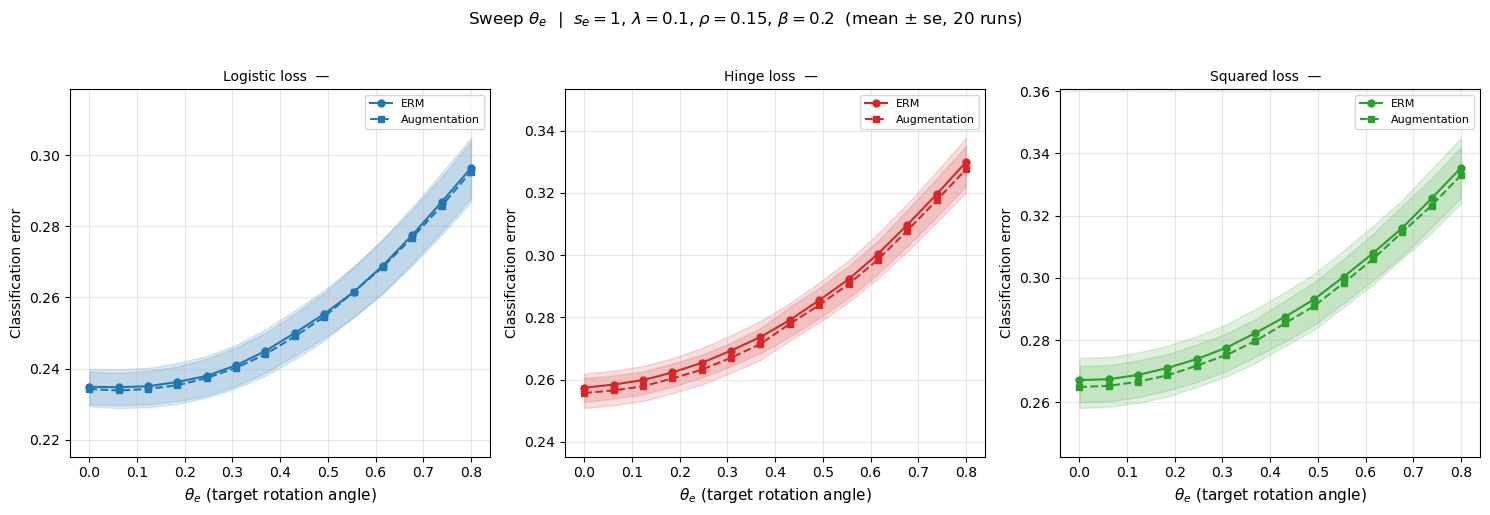

✓ theta_e sweep done


In [9]:
theta_e_grid = np.linspace(0.0, 0.8, 14)

res_the = sweep_param(
    theta_e_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: target_model(p, m, sigma, v, S_E_FIXED),
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: RHO_DEFAULT,
    beta_fn    = lambda v: BETA_DEFAULT,
    N_REP      = N_REP,
)

plot_sweep(
    res_the, theta_e_grid,
    xlabel  = r'$\theta_e$ (target rotation angle)',
    title   = '',
    suptitle= (f'Sweep $\\theta_e$  |  $s_e={S_E_FIXED}$, $\\lambda={LAM_DEFAULT}$, '
               f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
print('✓ theta_e sweep done')

## 8. Sweep $s_e$ — target bias difficulty

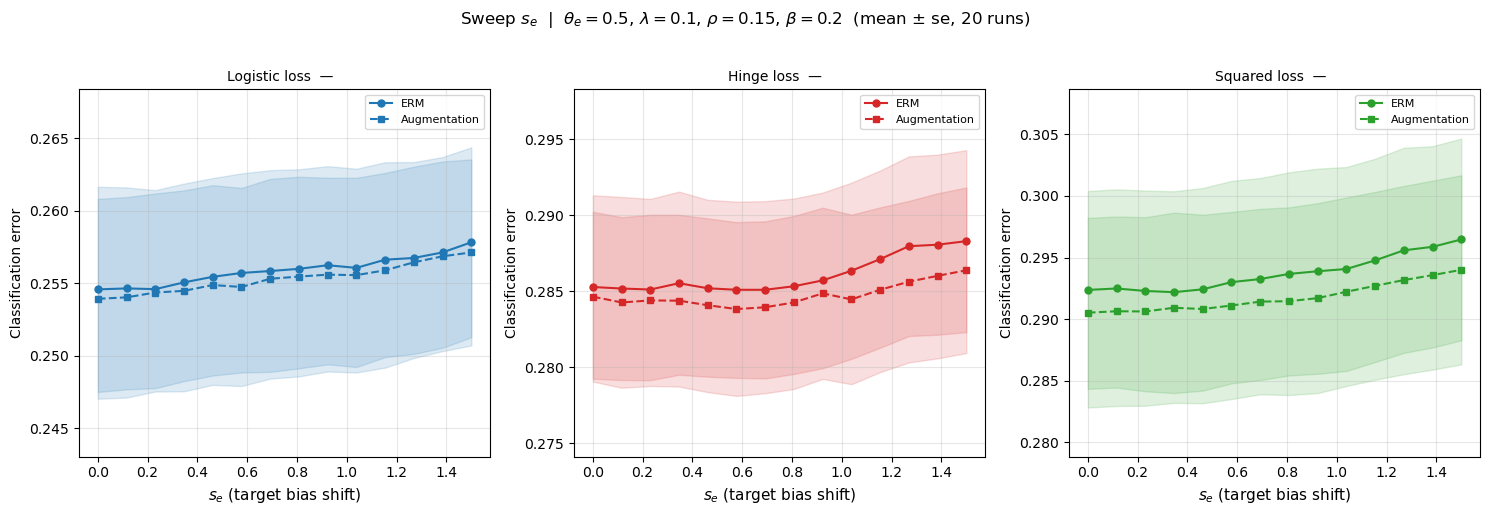

✓ s_e sweep done


In [10]:
s_e_grid = np.linspace(0.0, 1.5, 14)

res_se = sweep_param(
    s_e_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: target_model(p, m, sigma, THETA_E_FIXED, v),
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: RHO_DEFAULT,
    beta_fn    = lambda v: BETA_DEFAULT,
    N_REP      = N_REP,
)

plot_sweep(
    res_se, s_e_grid,
    xlabel  = r'$s_e$ (target bias shift)',
    title   = '',
    suptitle= (f'Sweep $s_e$  |  $\\theta_e={THETA_E_FIXED}$, $\\lambda={LAM_DEFAULT}$, '
               f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$  (mean ± se, {N_REP} runs)'),
)
print('✓ s_e sweep done')

## 9. Summary: augmentation advantage $\Delta = \text{err}_{\text{ERM}} - \text{err}_{\text{Augm}}$
Positive = augmentation helps. Shaded band = ±1 SE.

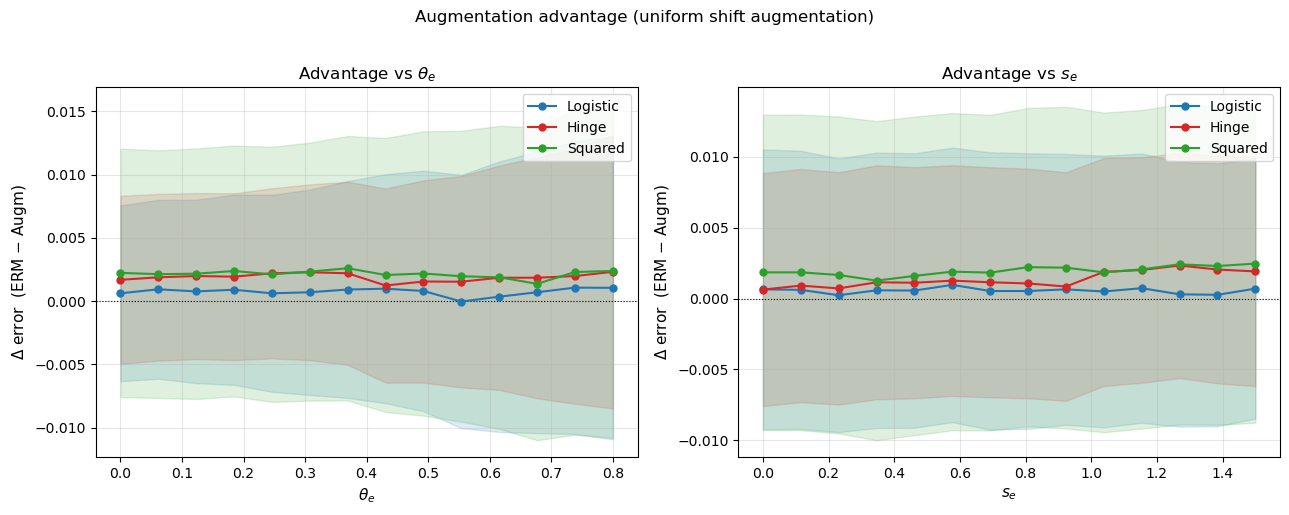

✓ Summary done


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, grid, xlabel, title in [
    (axes[0], res_the, theta_e_grid, r'$\theta_e$', r'Advantage vs $\theta_e$'),
    (axes[1], res_se,  s_e_grid,     r'$s_e$',      r'Advantage vs $s_e$'),
]:
    ax.axhline(0, color='k', lw=0.8, ls=':')
    for i, (name, col) in enumerate(zip(LOSS_NAMES, LOSS_COLORS)):
        delta = np.array(res['erm_mean'][i]) - np.array(res['augm_mean'][i])
        se_d  = np.sqrt(np.array(res['erm_std'][i])**2 + np.array(res['augm_std'][i])**2)
        ax.plot(grid, delta, color=col, marker='o', ms=5, label=name)
        ax.fill_between(grid, delta-se_d, delta+se_d, color=col, alpha=0.15)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(r'$\Delta$ error  (ERM $-$ Augm)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Augmentation advantage (uniform shift augmentation)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('✓ Summary done')

## 10. Structured shift: $\eta = s \cdot e_2$ vs uniform

**Hypothesis:** the uniform shift hurts because it perturbs the signal direction $e_1$.  
A shift along $e_2$ only (the nuisance direction of the target) should be beneficial.

We compare the two strategies side by side on the $\beta$ sweep.

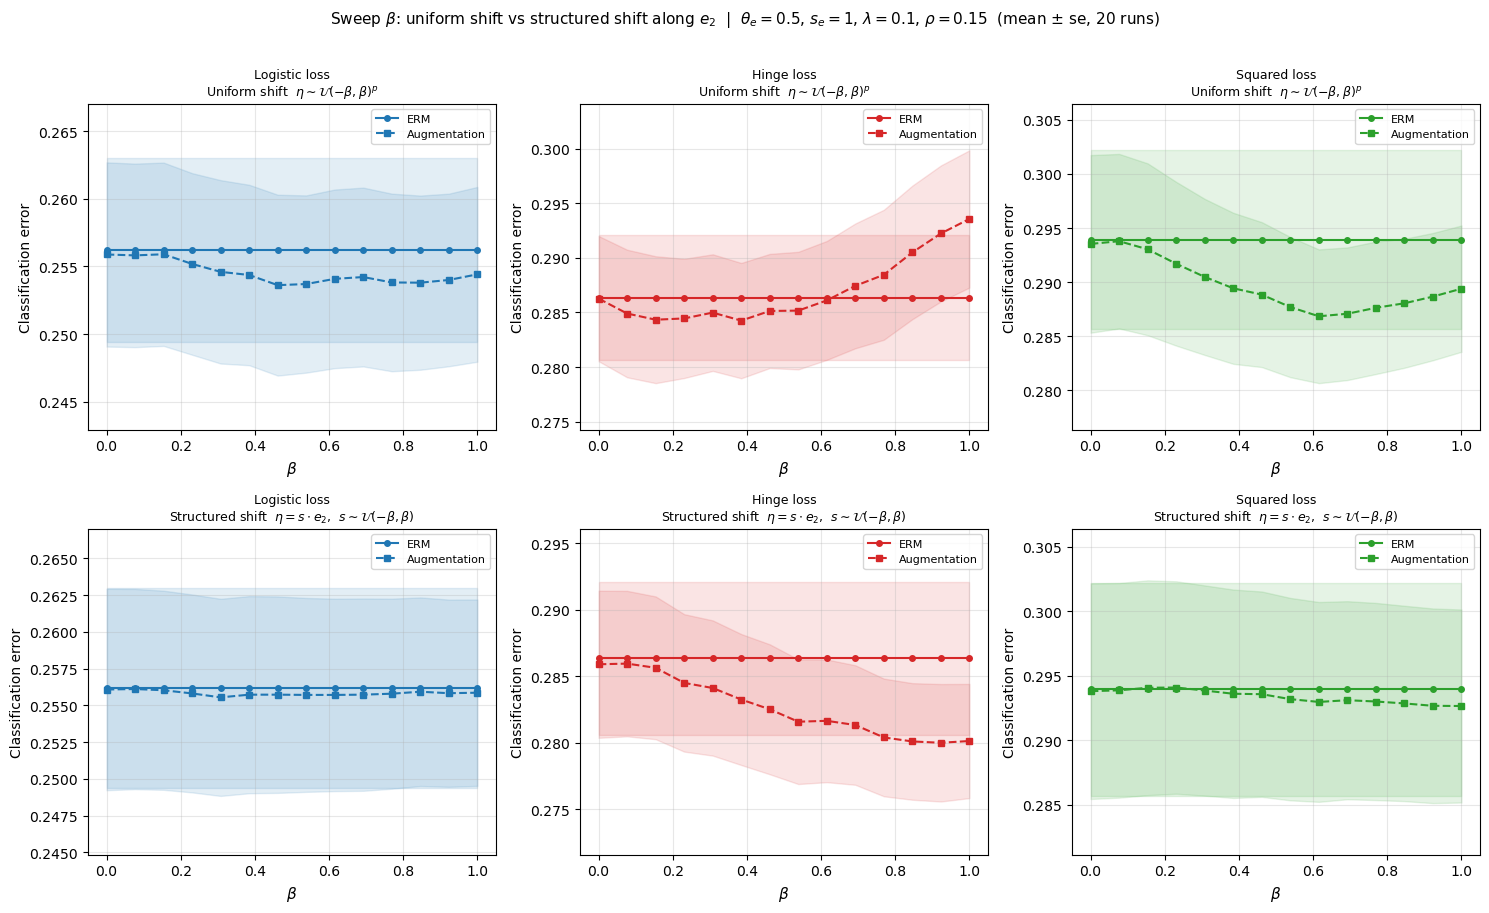

✓ Structured vs uniform shift comparison done


In [12]:
res_beta_e2 = sweep_param(
    beta_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: MOD_TGT,
    lam_fn     = lambda v: LAM_DEFAULT,
    rho_fn     = lambda v: RHO_DEFAULT,
    beta_fn    = lambda v: v,
    N_REP      = N_REP,
    make_tr    = make_transform_e2,
)

# ── Plot: 2 rows × 3 losses ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    r'Sweep $\beta$: uniform shift vs structured shift along $e_2$  |  '
    f'$\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
    f'$\\lambda={LAM_DEFAULT}$, $\\rho={RHO_DEFAULT}$  (mean ± se, {N_REP} runs)',
    fontsize=11, y=1.01
)

labels = [
    r'Uniform shift  $\eta \sim \mathcal{U}(-\beta,\beta)^p$',
    r'Structured shift  $\eta = s \cdot e_2$,  $s \sim \mathcal{U}(-\beta,\beta)$',
]
for row, (res, label) in enumerate([(res_beta_uniform, labels[0]),
                                     (res_beta_e2,      labels[1])]):
    for i, (ax, name, col) in enumerate(zip(axes[row], LOSS_NAMES, LOSS_COLORS)):
        em  = np.array(res['erm_mean'][i]);  es  = np.array(res['erm_std'][i])
        am  = np.array(res['augm_mean'][i]); as_ = np.array(res['augm_std'][i])
        ax.plot(beta_grid, em,  color=col, ls='-',  marker='o', ms=4, label='ERM')
        ax.fill_between(beta_grid, em-es,  em+es,  color=col, alpha=0.12)
        ax.plot(beta_grid, am,  color=col, ls='--', marker='s', ms=4, label='Augmentation')
        ax.fill_between(beta_grid, am-as_, am+as_, color=col, alpha=0.12)
        ax.set_xlabel(r'$\beta$', fontsize=11)
        ax.set_title(f'{name} loss\n{label}', fontsize=9)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        all_v = np.concatenate([em-es, em+es, am-as_, am+as_])
        lo, hi = all_v.min(), all_v.max()
        mg = max((hi-lo)*0.20, 0.004)
        ax.set_ylim(max(0, lo-mg), min(0.5, hi+mg))
        ax.set_ylabel('Classification error', fontsize=10)

plt.tight_layout()
plt.show()
print('✓ Structured vs uniform shift comparison done')

## 11. Delta: structured vs uniform shift
Does augmenting along $e_2$ give a clearer advantage over ERM?

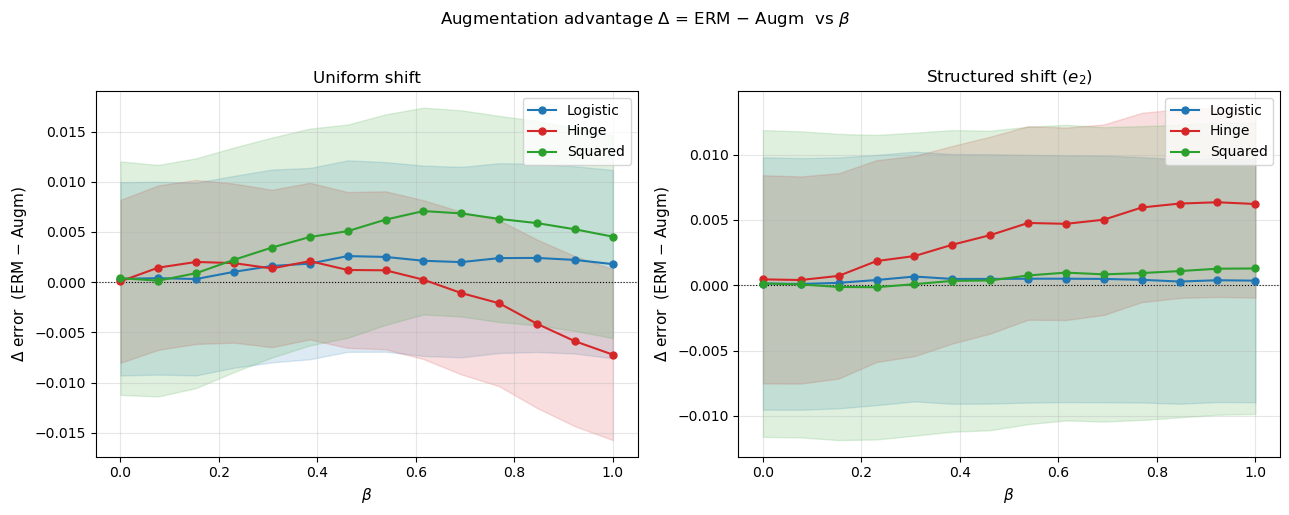

✓ Delta comparison done


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r'Augmentation advantage $\Delta$ = ERM $-$ Augm  vs $\beta$', fontsize=12, y=1.02)

for ax, (res, label) in zip(axes, [(res_beta_uniform, 'Uniform shift'),
                                    (res_beta_e2,      r'Structured shift ($e_2$)')]):
    ax.axhline(0, color='k', lw=0.8, ls=':')
    for i, (name, col) in enumerate(zip(LOSS_NAMES, LOSS_COLORS)):
        delta = np.array(res['erm_mean'][i]) - np.array(res['augm_mean'][i])
        se_d  = np.sqrt(np.array(res['erm_std'][i])**2 + np.array(res['augm_std'][i])**2)
        ax.plot(beta_grid, delta, color=col, marker='o', ms=5, label=name)
        ax.fill_between(beta_grid, delta-se_d, delta+se_d, color=col, alpha=0.15)
    ax.set_xlabel(r'$\beta$', fontsize=11)
    ax.set_ylabel(r'$\Delta$ error  (ERM $-$ Augm)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Delta comparison done')

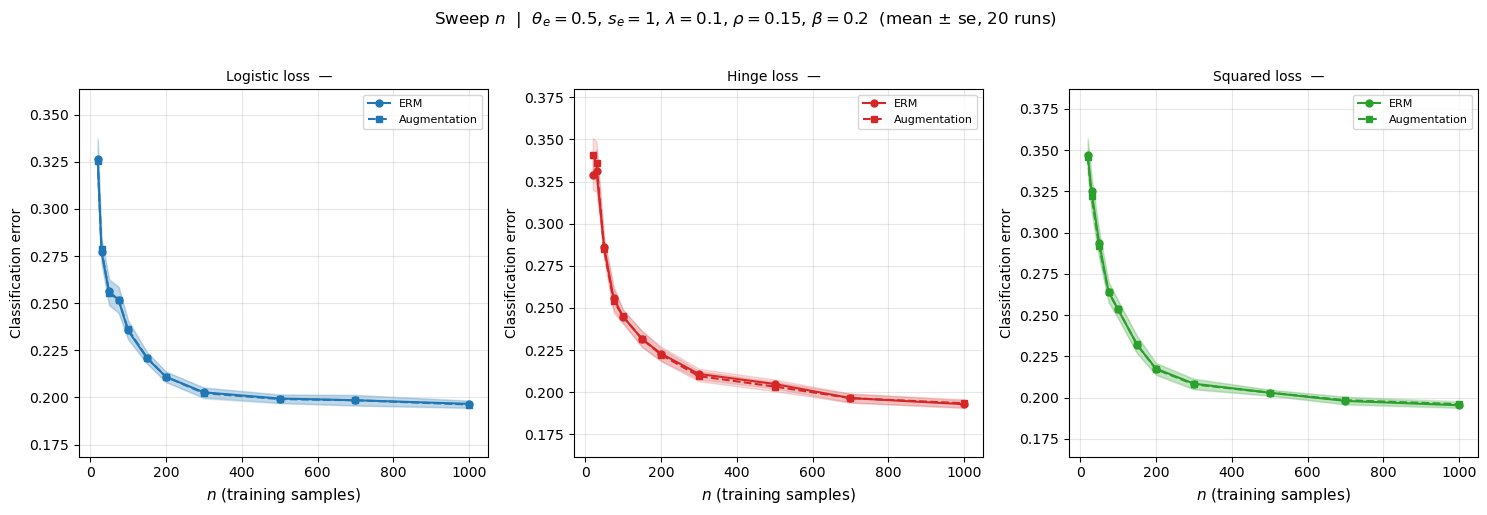

✓ n sweep done


In [15]:
n_grid = [20, 30, 50, 75, 100, 150, 200, 300, 500, 700, 1000]
K = 3
erm_mean_n  = [[] for _ in range(K)]
augm_mean_n = [[] for _ in range(K)]
erm_std_n   = [[] for _ in range(K)]
augm_std_n  = [[] for _ in range(K)]

for n in n_grid:
    rep_erm  = [[] for _ in range(K)]
    rep_augm = [[] for _ in range(K)]
    for seed in range(N_REP):
        reg = make_reg(p, LAM_DEFAULT)
        for i, loss in enumerate(make_losses(p)):
            rng_tr = np.random.default_rng(seed * 100 + i)
            th_erm, _, _ = et.ERMTrainer(model=MOD_SRC, loss=loss,
                                          regularizer=reg).sample_theta_hat(n=n, rng=rng_tr)
            rng_te = np.random.default_rng(seed * 100 + i + 50)
            rep_erm[i].append(MOD_TGT.error_classif_emp([th_erm], n_test=n_test, rng=rng_te))
            rng_tr2 = np.random.default_rng(seed * 100 + i)
            tr = make_transform_uniform(p, RHO_DEFAULT, BETA_DEFAULT, rng_tr2)
            th_augm, _, _ = augm.DataAugmTrainer(model=MOD_SRC, loss=loss, regularizer=reg,
                                                  transform=tr, K_augm=K_augm).sample_theta_hat(
                                                  n=n, rng=rng_tr2)
            rng_te = np.random.default_rng(seed * 100 + i + 50)
            rep_augm[i].append(MOD_TGT.error_classif_emp([th_augm], n_test=n_test, rng=rng_te))
    for i in range(K):
        erm_mean_n[i].append(np.mean(rep_erm[i]))
        augm_mean_n[i].append(np.mean(rep_augm[i]))
        erm_std_n[i].append(np.std(rep_erm[i]) / np.sqrt(N_REP))
        augm_std_n[i].append(np.std(rep_augm[i]) / np.sqrt(N_REP))

plot_sweep(
    dict(erm_mean=erm_mean_n, augm_mean=augm_mean_n,
         erm_std=erm_std_n,   augm_std=augm_std_n),
    n_grid,
    xlabel  = r'$n$ (training samples)',
    title   = '',
    suptitle= (f'Sweep $n$  |  $\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
               f'$\\lambda={LAM_DEFAULT}$, $\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$'
               f'  (mean ± se, {N_REP} runs)'),
)
print('✓ n sweep done')

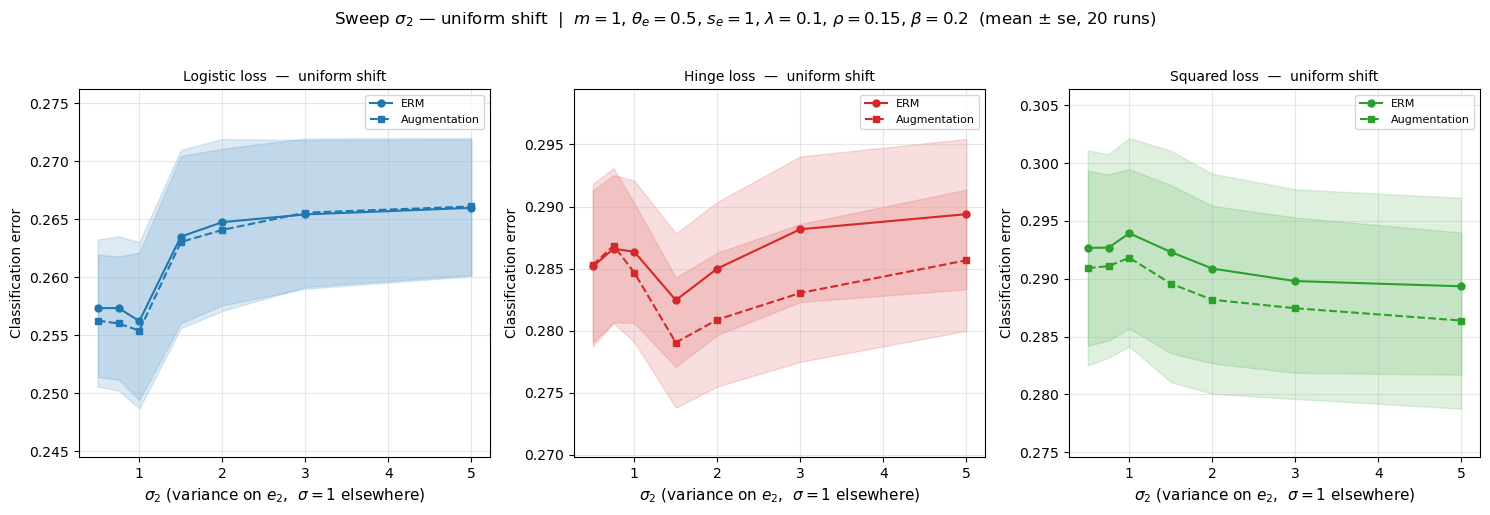

✓ sigma_nuisance sweep uniform done


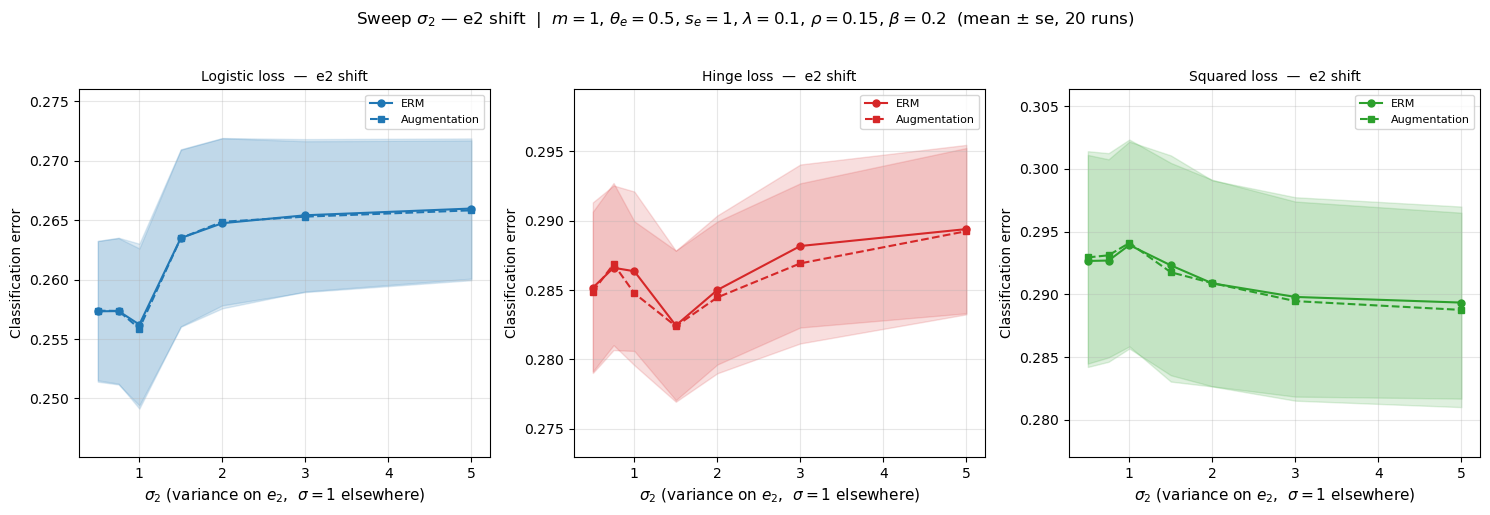

✓ sigma_nuisance sweep e2 done


In [19]:
sigma_nuisance_grid = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]
K = 3

def source_model_aniso(p, m, sigma, sigma2):
    """Covariance isotrope sauf sur e2 qui a variance sigma2**2."""
    C = sigma**2 * np.eye(p)
    C[1, 1] = sigma2**2
    mu = m * e1_vec(p)
    return dm.MultiClassModel(
        components=[dm.GaussianModel(p=p, mu=-mu, C=C),
                    dm.GaussianModel(p=p, mu=+mu, C=C)],
        gamma=[0.5, 0.5], y_values=[-1.0, +1.0])

def target_model_aniso(p, m, sigma, sigma2, theta_e, s_e):
    C = sigma**2 * np.eye(p)
    C[1, 1] = sigma2**2
    mu = m * e1_vec(p)
    R = np.eye(p)
    R[0,0] =  np.cos(theta_e); R[0,1] = -np.sin(theta_e)
    R[1,0] =  np.sin(theta_e); R[1,1] =  np.cos(theta_e)
    b = np.zeros(p); b[1] = s_e
    return dm.MultiClassModel(
        components=[dm.GaussianModel(p=p, mu=R@(-mu)+b, C=C),
                    dm.GaussianModel(p=p, mu=R@(+mu)+b, C=C)],
        gamma=[0.5, 0.5], y_values=[-1.0, +1.0])

for transform_name, make_tr in [('uniform', make_transform_uniform), ('e2', make_transform_e2)]:
    erm_mean_a  = [[] for _ in range(K)]
    augm_mean_a = [[] for _ in range(K)]
    erm_std_a   = [[] for _ in range(K)]
    augm_std_a  = [[] for _ in range(K)]

    for s2 in sigma_nuisance_grid:
        mod_src_a = source_model_aniso(p, m, sigma, s2)
        mod_tgt_a = target_model_aniso(p, m, sigma, s2, THETA_E_FIXED, S_E_FIXED)
        rep_erm  = [[] for _ in range(K)]
        rep_augm = [[] for _ in range(K)]
        for seed in range(N_REP):
            reg = make_reg(p, LAM_DEFAULT)
            for i, loss in enumerate(make_losses(p)):
                rng_tr = np.random.default_rng(seed * 100 + i)
                th_erm, _, _ = et.ERMTrainer(model=mod_src_a, loss=loss,
                                              regularizer=reg).sample_theta_hat(n=n_train, rng=rng_tr)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_erm[i].append(mod_tgt_a.error_classif_emp([th_erm], n_test=n_test, rng=rng_te))
                rng_tr2 = np.random.default_rng(seed * 100 + i)
                tr = make_tr(p, RHO_DEFAULT, BETA_DEFAULT, rng_tr2)
                th_augm, _, _ = augm.DataAugmTrainer(model=mod_src_a, loss=loss, regularizer=reg,
                                                      transform=tr, K_augm=K_augm).sample_theta_hat(
                                                      n=n_train, rng=rng_tr2)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep_augm[i].append(mod_tgt_a.error_classif_emp([th_augm], n_test=n_test, rng=rng_te))
        for i in range(K):
            erm_mean_a[i].append(np.mean(rep_erm[i]))
            augm_mean_a[i].append(np.mean(rep_augm[i]))
            erm_std_a[i].append(np.std(rep_erm[i]) / np.sqrt(N_REP))
            augm_std_a[i].append(np.std(rep_augm[i]) / np.sqrt(N_REP))

    plot_sweep(
        dict(erm_mean=erm_mean_a, augm_mean=augm_mean_a,
             erm_std=erm_std_a,   augm_std=augm_std_a),
        sigma_nuisance_grid,
        xlabel  = r'$\sigma_2$ (variance on $e_2$,  $\sigma=1$ elsewhere)',
        title   = f'{transform_name} shift',
        suptitle= (f'Sweep $\\sigma_2$ — {transform_name} shift  |  $m=1$, '
                   f'$\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, '
                   f'$\\lambda={LAM_DEFAULT}$, $\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$'
                   f'  (mean ± se, {N_REP} runs)'),
    )
    print(f'✓ sigma_nuisance sweep {transform_name} done')

val=0.000  converged=False  iter=200
val=0.062  converged=False  iter=200
val=0.123  converged=False  iter=200
val=0.185  converged=False  iter=200
val=0.246  converged=False  iter=200
val=0.308  converged=False  iter=200
val=0.369  converged=False  iter=200
val=0.431  converged=False  iter=200
val=0.492  converged=False  iter=200
val=0.554  converged=False  iter=200
val=0.615  converged=False  iter=200
val=0.677  converged=False  iter=200
val=0.738  converged=False  iter=200
val=0.800  converged=False  iter=200


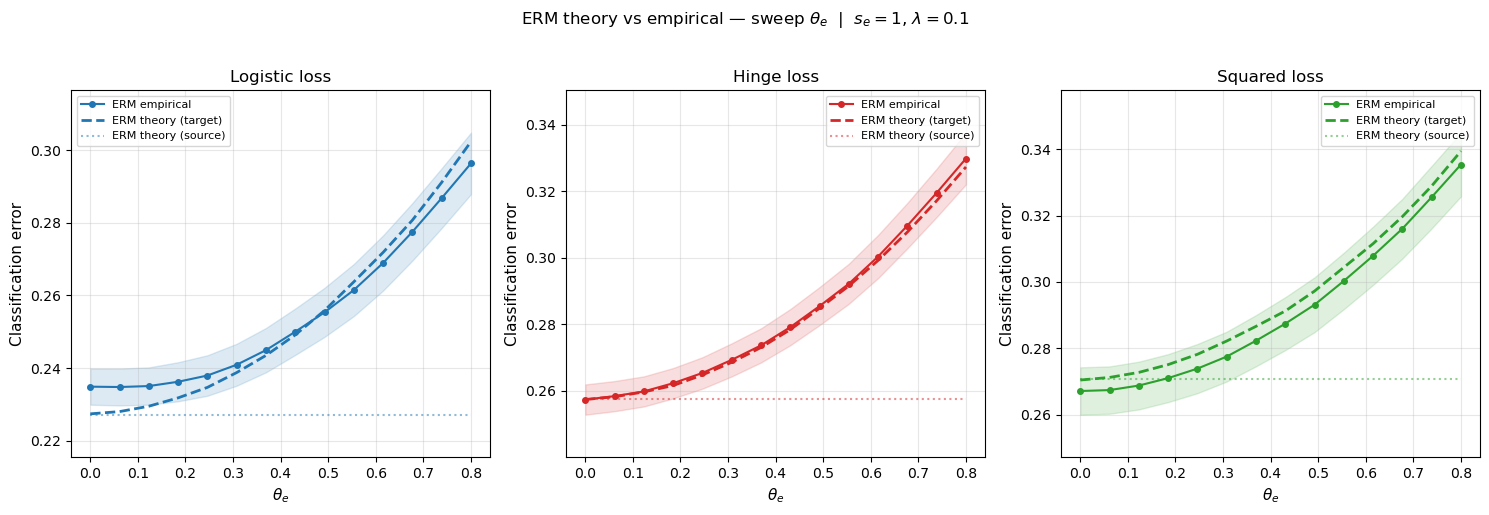

val=0.000  converged=False  iter=200
val=0.115  converged=False  iter=200
val=0.231  converged=False  iter=200
val=0.346  converged=False  iter=200
val=0.462  converged=False  iter=200
val=0.577  converged=False  iter=200
val=0.692  converged=False  iter=200
val=0.808  converged=False  iter=200
val=0.923  converged=False  iter=200
val=1.038  converged=False  iter=200
val=1.154  converged=False  iter=200
val=1.269  converged=False  iter=200
val=1.385  converged=False  iter=200
val=1.500  converged=False  iter=200


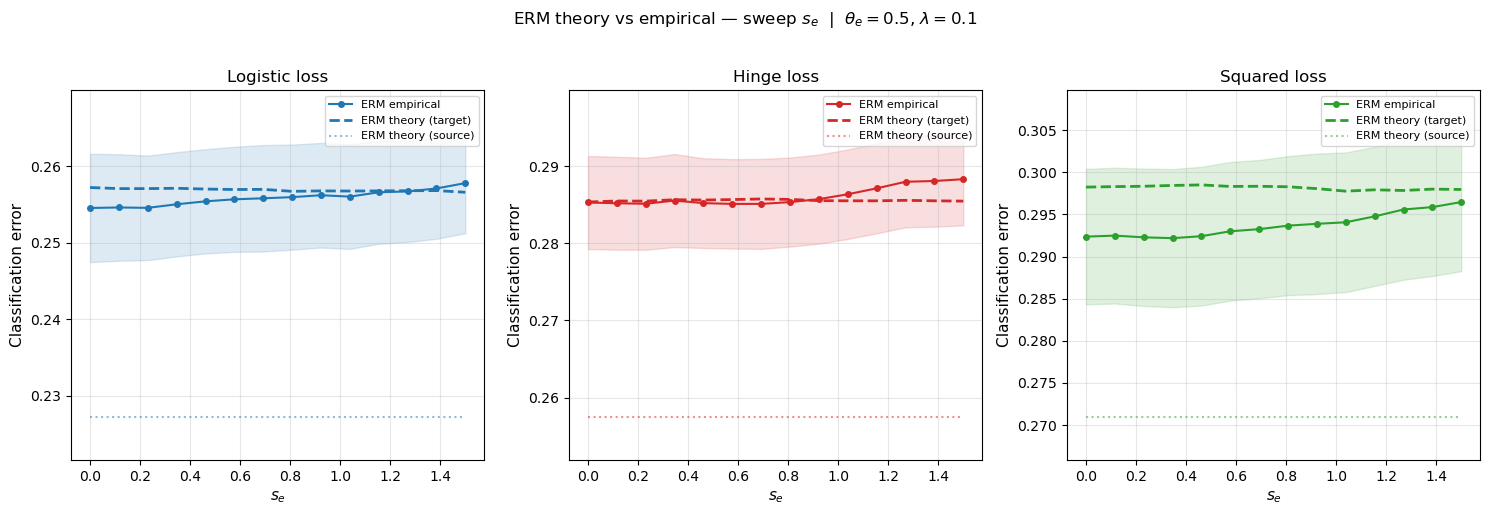

val=0.500  converged=False  iter=200
val=0.750  converged=False  iter=200
val=1.000  converged=False  iter=200
val=1.500  converged=False  iter=200
val=2.000  converged=False  iter=200
val=3.000  converged=False  iter=200
val=5.000  converged=False  iter=200


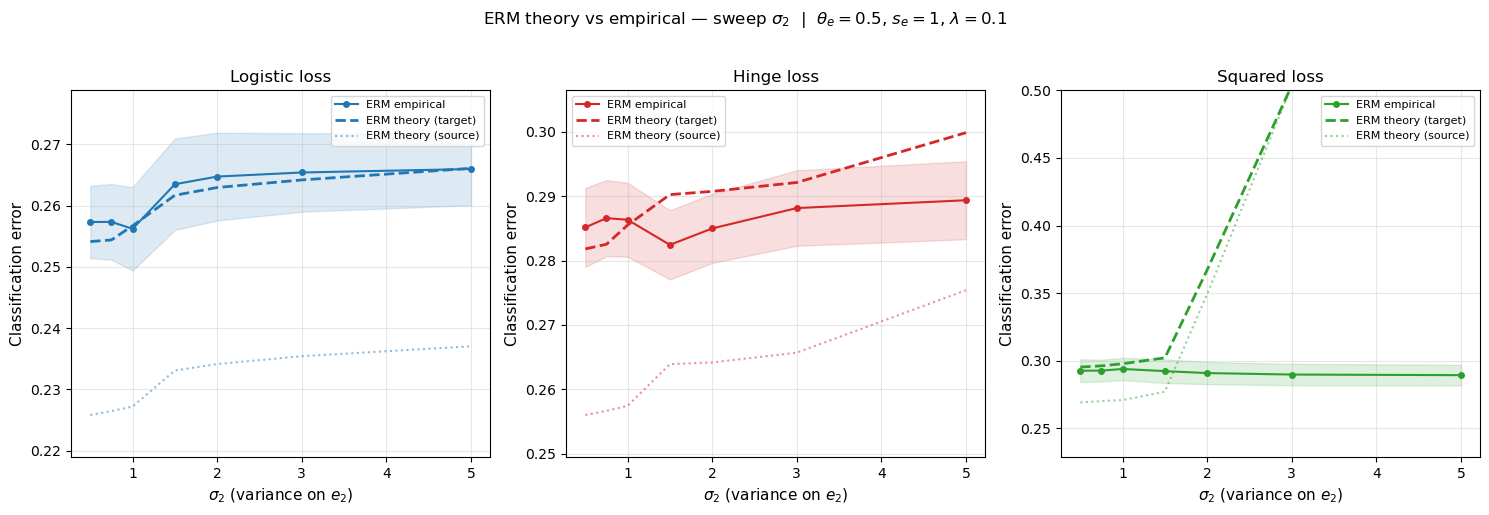

In [21]:
# ── Fonction générique : théorie ERM sur un sweep ────────────────────────────
def theory_erm_sweep(param_grid, mod_src_fn, mod_tgt_fn, lam=LAM_DEFAULT,
                     n_train=n_train, mc_samples=10000):
    th_err_src = [[] for _ in range(3)]
    th_err_tgt = [[] for _ in range(3)]
    for val in param_grid:
        mod_src = mod_src_fn(val)
        mod_tgt = mod_tgt_fn(val)
        reg = make_reg(p, lam)
        for i, loss in enumerate(make_losses(p)):
            solver = et.TheoryFixedPointSolver(
                model       = mod_src,
                loss        = loss,
                regularizer = reg,
                n_train     = n_train,
                mc_samples  = mc_samples,
                rng         = np.random.default_rng(0),
            )
            sol = solver.solve(max_iter=200, damping=0.3, tol=1e-6)
            mu_star = sol['mu']
            alpha   = sol['alpha']
            th_err_src[i].append(mod_src.error_classif_th(
                mu_star, alpha=alpha, num_trials=50000, rng=np.random.default_rng(1)))
            th_err_tgt[i].append(mod_tgt.error_classif_th(
                mu_star, alpha=alpha, num_trials=50000, rng=np.random.default_rng(1)))
        print(f'val={val:.3f}  converged={sol["converged"]}  iter={sol["num_iter"]}')
    return th_err_src, th_err_tgt

def plot_theory_vs_emp(res_emp, th_src, th_tgt, grid, xlabel, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(suptitle, fontsize=12, y=1.02)
    for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
        em = np.array(res_emp['erm_mean'][i]); es = np.array(res_emp['erm_std'][i])
        ax.plot(grid, em, color=col, ls='-', marker='o', ms=4, label='ERM empirical')
        ax.fill_between(grid, em-es, em+es, color=col, alpha=0.15)
        ax.plot(grid, th_tgt[i], color=col, ls='--', lw=2, label='ERM theory (target)')
        ax.plot(grid, th_src[i], color=col, ls=':', lw=1.5, alpha=0.5, label='ERM theory (source)')
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(f'{name} loss', fontsize=12)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        all_v = np.concatenate([em-es, em+es, th_tgt[i], th_src[i]])
        lo, hi = all_v.min(), all_v.max()
        mg = max((hi-lo)*0.15, 0.004)
        ax.set_ylim(max(0, lo-mg), min(0.5, hi+mg))
        ax.set_ylabel('Classification error', fontsize=11)
    plt.tight_layout(); plt.show()

# ── Sweep theta_e ─────────────────────────────────────────────────────────────
th_src_the, th_tgt_the = theory_erm_sweep(
    theta_e_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: target_model(p, m, sigma, v, S_E_FIXED),
)
plot_theory_vs_emp(
    res_the, th_src_the, th_tgt_the, theta_e_grid,
    xlabel   = r'$\theta_e$',
    suptitle = (f'ERM theory vs empirical — sweep $\\theta_e$  |  '
                f'$s_e={S_E_FIXED}$, $\\lambda={LAM_DEFAULT}$'),
)

# ── Sweep s_e ─────────────────────────────────────────────────────────────────
th_src_se, th_tgt_se = theory_erm_sweep(
    s_e_grid,
    mod_src_fn = lambda v: MOD_SRC,
    mod_tgt_fn = lambda v: target_model(p, m, sigma, THETA_E_FIXED, v),
)
plot_theory_vs_emp(
    res_se, th_src_se, th_tgt_se, s_e_grid,
    xlabel   = r'$s_e$',
    suptitle = (f'ERM theory vs empirical — sweep $s_e$  |  '
                f'$\\theta_e={THETA_E_FIXED}$, $\\lambda={LAM_DEFAULT}$'),
)

# ── Sweep sigma_nuisance ───────────────────────────────────────────────────────
th_src_s2, th_tgt_s2 = theory_erm_sweep(
    sigma_nuisance_grid,
    mod_src_fn = lambda v: source_model_aniso(p, m, sigma, v),
    mod_tgt_fn = lambda v: target_model_aniso(p, m, sigma, v, THETA_E_FIXED, S_E_FIXED),
)
plot_theory_vs_emp(
    dict(erm_mean=erm_mean_a, augm_mean=augm_mean_a,
         erm_std=erm_std_a,   augm_std=augm_std_a),
    th_src_s2, th_tgt_s2, sigma_nuisance_grid,
    xlabel   = r'$\sigma_2$ (variance on $e_2$)',
    suptitle = (f'ERM theory vs empirical — sweep $\\sigma_2$  |  '
                f'$\\theta_e={THETA_E_FIXED}$, $s_e={S_E_FIXED}$, $\\lambda={LAM_DEFAULT}$'),
)

In [ ]:
def compute_augmented_moments(p, m, sigma, rho, beta,
                               make_tr_fn, n_mc=20000, rng=None):
    """
    Calcule mu'_k et C'_k — les moments de T(x)|y=k — par Monte Carlo.

    Pour chaque classe k, tire n_mc samples x ~ N(mu_k, C_k),
    applique n_mc transformations independantes T, et estime
    empiriquement mu'_k = E[T(x)|y=k] et C'_k = Cov(T(x)|y=k).
    """
    if rng is None:
        rng = np.random.default_rng(42)

    C_base = sigma**2 * np.eye(p)
    mus    = [-m * e1_vec(p), +m * e1_vec(p)]

    mus_eff = []
    covs_eff = []

    for mu_k in mus:
        # Tire n_mc samples x ~ N(mu_k, C_base)
        X_k = rng.multivariate_normal(mu_k, C_base, size=n_mc)

        # Applique une transformation independante a chaque sample
        X_aug = np.zeros_like(X_k)
        for j in range(n_mc):
            tr = make_tr_fn(p, rho, beta, rng)
            X_aug[j] = tr(X_k[j:j+1])[0]  # shape (1,p) -> (p,)

        mu_eff  = np.mean(X_aug, axis=0)
        cov_eff = np.cov(X_aug, rowvar=False)

        mus_eff.append(mu_eff)
        covs_eff.append(cov_eff)

    return mus_eff, covs_eff


def augmented_source_model(p, m, sigma, rho, beta,
                            make_tr_fn, n_mc=20000, rng=None):
    """
    Construit le modele source effectif vu par l'ERM augmente.
    Memes gamma et y_values que le modele source original,
    mais avec moments (mu'_k, C'_k) calcules par MC.
    """
    mus_eff, covs_eff = compute_augmented_moments(
        p, m, sigma, rho, beta, make_tr_fn, n_mc=n_mc, rng=rng)

    return dm.MultiClassModel(
        components=[dm.GaussianModel(p=p, mu=mus_eff[0], C=covs_eff[0]),
                    dm.GaussianModel(p=p, mu=mus_eff[1], C=covs_eff[1])],
        gamma=[0.5, 0.5],
        y_values=[-1.0, +1.0],
    )


# ── Test rapide : verifie que les moments sont coherents ─────────────────────
rng_test = np.random.default_rng(0)
mod_aug_test = augmented_source_model(
    p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
    make_tr_fn=make_transform_uniform, n_mc=20000, rng=rng_test)

params = mod_aug_test.class_params()
print('mu_eff class 0 (premiers coords):',
      np.round(params['mus'][0][:4], 4))
print('mu_eff class 1 (premiers coords):',
      np.round(params['mus'][1][:4], 4))
print('diag C_eff class 0 (premiers coords):',
      np.round(np.diag(params['covs'][0])[:4], 4))
print()
print(f'Expected mu_0[0] ~ {-m:.2f},  mu_1[0] ~ {+m:.2f}  (signal inchange)')
print(f'Expected C_eff[0,0] ~ {sigma**2:.2f} + rotation_term')
print(f'Expected C_eff[1,1] ~ {sigma**2:.2f} + beta^2/3 = '
      f'{sigma**2 + BETA_DEFAULT**2/3:.4f}  (shift sur coord 1)')

mu_eff class 0 (premiers coords): [-1.0064e+00 -3.7000e-03  7.0000e-04  6.7000e-03]
mu_eff class 1 (premiers coords): [ 0.9946 -0.0052  0.0053  0.0082]
diag C_eff class 0 (premiers coords): [1.0174 1.0041 1.0121 0.9964]

Expected mu_0[0] ~ -1.00,  mu_1[0] ~ 1.00  (signal inchange)
Expected C_eff[0,0] ~ 1.00 + rotation_term
Expected C_eff[1,1] ~ 1.00 + beta^2/3 = 1.0133  (shift sur coord 1)


loss=Logistic   val=0.000  converged=False  iter=500  damping_final=4.47e-03  nu2A=[8.7297 8.7626]  (-> 1 = divergence)
loss=Logistic   val=0.062  converged=False  iter=500  damping_final=4.47e-03  nu2A=[7.0252 7.0602]  (-> 1 = divergence)
loss=Logistic   val=0.123  converged=False  iter=500  damping_final=4.47e-03  nu2A=[6.9401 6.9754]  (-> 1 = divergence)
loss=Logistic   val=0.185  converged=False  iter=500  damping_final=4.47e-03  nu2A=[6.9351 6.9704]  (-> 1 = divergence)
loss=Logistic   val=0.246  converged=False  iter=500  damping_final=4.47e-03  nu2A=[6.9348 6.9701]  (-> 1 = divergence)
loss=Logistic   val=0.308  converged=False  iter=500  damping_final=4.47e-03  nu2A=[6.9348 6.97  ]  (-> 1 = divergence)
loss=Logistic   val=0.369  converged=True  iter= 42  damping_final=1.54e-02  nu2A=[6.9348 6.97  ]  (-> 1 = divergence)
loss=Logistic   val=0.431  converged=True  iter= 10  damping_final=3.16e-02  nu2A=[6.9348 6.97  ]  (-> 1 = divergence)
loss=Logistic   val=0.492  converged=True 

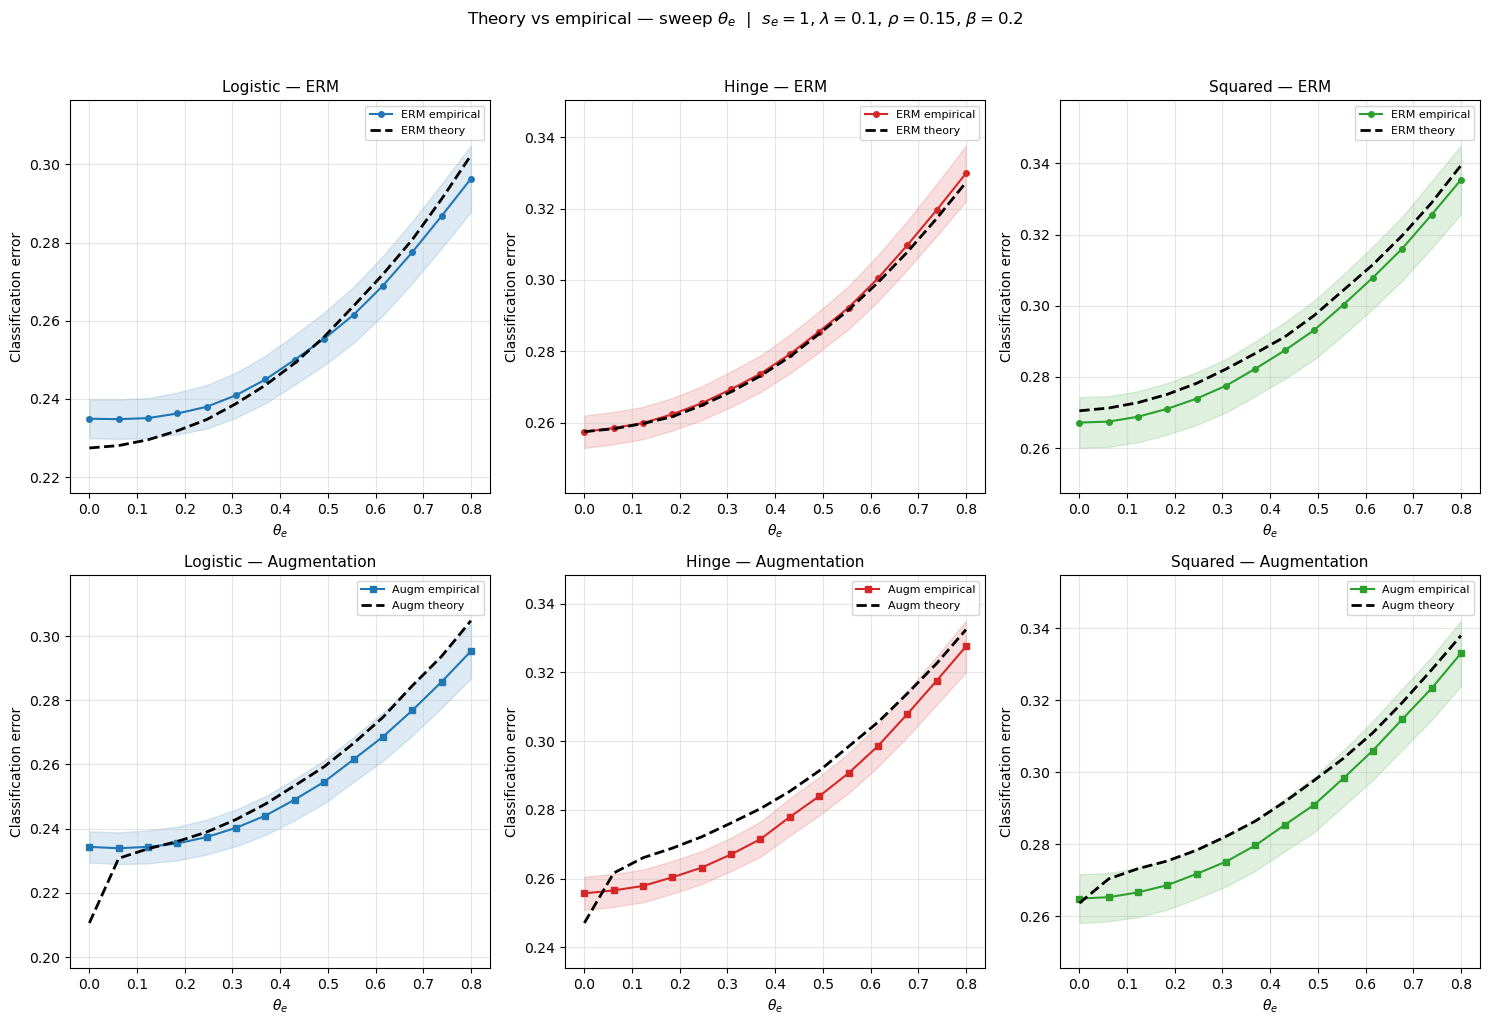

✓ 6-panel theory vs empirical done


In [27]:
# ── Sweep theta_e : theorie augm vs theorie ERM vs empirique ─────────────────
mod_aug = augmented_source_model(
    p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
    make_tr_fn=make_transform_uniform, n_mc=20000,
    rng=np.random.default_rng(42))

th_src_augm_the, th_tgt_augm_the = theory_erm_sweep_robust(
    theta_e_grid,
    mod_src_fn = lambda v: mod_aug,
    mod_tgt_fn = lambda v: target_model(p, m, sigma, v, S_E_FIXED),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(
    r'Theory vs empirical — sweep $\theta_e$  |  '
    f'$s_e={S_E_FIXED}$, $\\lambda={LAM_DEFAULT}$, '
    f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$',
    fontsize=12, y=1.02)

for i, (name, col) in enumerate(zip(LOSS_NAMES, LOSS_COLORS)):

    # ── Ligne 0 : ERM ────────────────────────────────────────────────────────
    ax = axes[0, i]
    em = np.array(res_the['erm_mean'][i]); es = np.array(res_the['erm_std'][i])
    ax.plot(theta_e_grid, em, color=col, ls='-', marker='o', ms=4, label='ERM empirical')
    ax.fill_between(theta_e_grid, em-es, em+es, color=col, alpha=0.15)
    ax.plot(theta_e_grid, th_tgt_the[i], color='k', ls='--', lw=2, label='ERM theory')
    ax.set_title(f'{name} — ERM', fontsize=11)
    ax.set_xlabel(r'$\theta_e$', fontsize=10)
    ax.set_ylabel('Classification error', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([em-es, em+es, th_tgt_the[i]])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 0.004)
    ax.set_ylim(max(0, lo-mg), min(0.5, hi+mg))

    # ── Ligne 1 : Augm ───────────────────────────────────────────────────────
    ax = axes[1, i]
    am = np.array(res_the['augm_mean'][i]); as_ = np.array(res_the['augm_std'][i])
    ax.plot(theta_e_grid, am, color=col, ls='-', marker='s', ms=4, label='Augm empirical')
    ax.fill_between(theta_e_grid, am-as_, am+as_, color=col, alpha=0.15)
    ax.plot(theta_e_grid, th_tgt_augm_the[i], color='k', ls='--', lw=2, label='Augm theory')
    ax.set_title(f'{name} — Augmentation', fontsize=11)
    ax.set_xlabel(r'$\theta_e$', fontsize=10)
    ax.set_ylabel('Classification error', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([am-as_, am+as_, th_tgt_augm_the[i]])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 0.004)
    ax.set_ylim(max(0, lo-mg), min(0.5, hi+mg))

plt.tight_layout()
plt.show()
print('✓ 6-panel theory vs empirical done')

theta_e=0.05 done
theta_e=0.10 done
theta_e=0.20 done
theta_e=0.30 done
theta_e=0.50 done
theta_e=0.70 done
theta_e=1.00 done
s_e=0.05 done
s_e=0.10 done
s_e=0.30 done
s_e=0.50 done
s_e=0.80 done
s_e=1.20 done
s_e=1.50 done


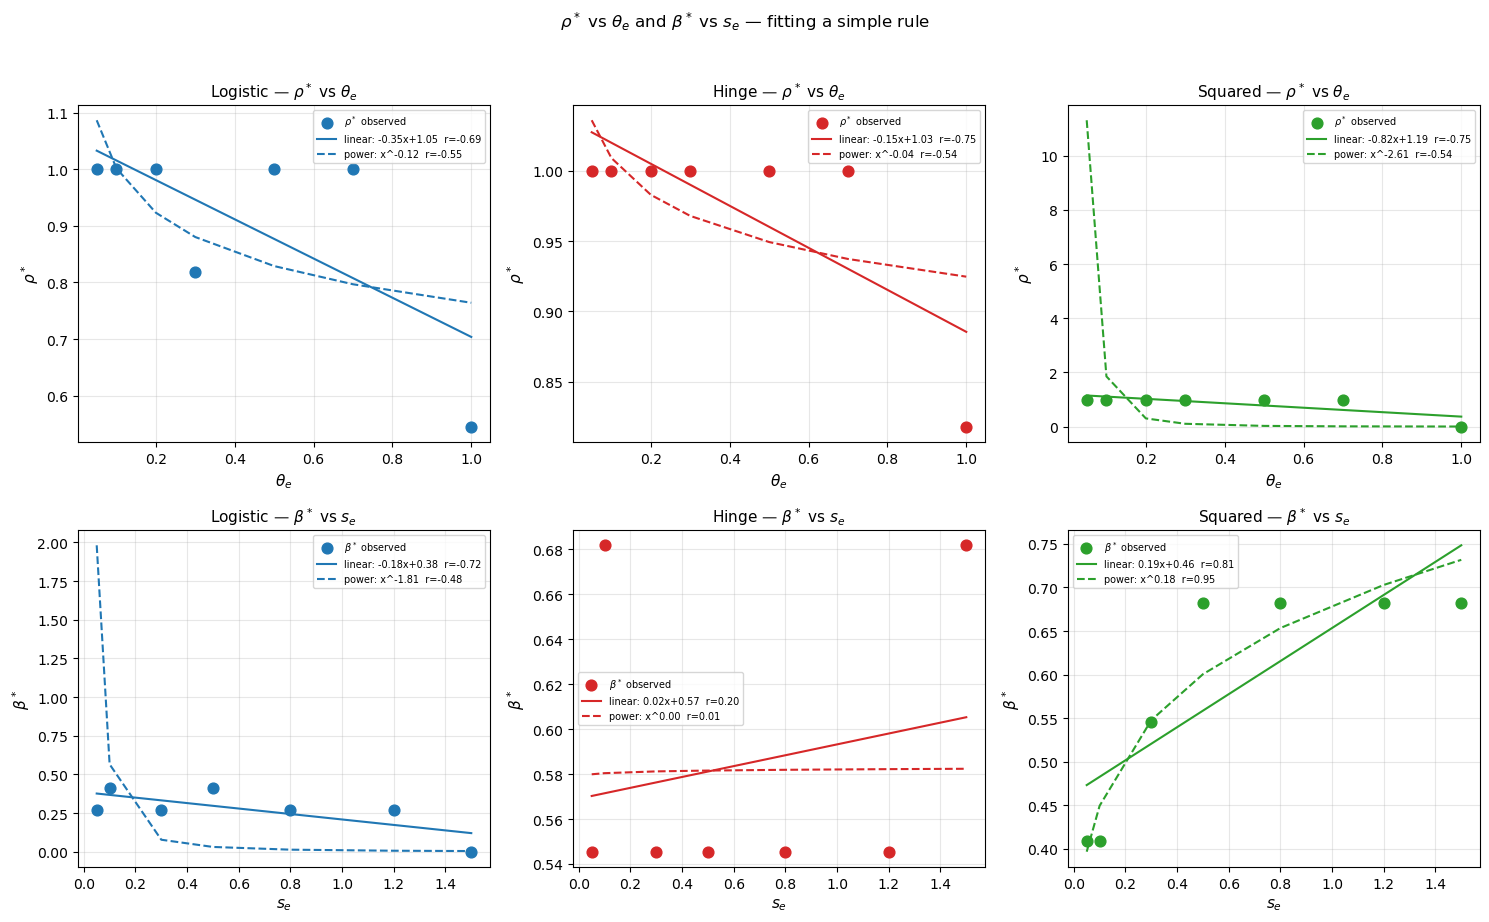

✓ Optimal rule fitting done


In [31]:
from scipy.stats import linregress
import numpy as np

# Grille de valeurs à tester
theta_e_vals = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
s_e_vals     = [0.05, 0.1, 0.3, 0.5, 0.8, 1.2, 1.5]
rho_grid     = np.linspace(0., 1.0, 12)
beta_grid    = np.linspace(0., 1.5, 12)
N_REP_OPT    = 5

# ── Trouver rho* pour chaque theta_e (beta=0 fixé) ───────────────────────────
rho_stars = {name: [] for name in LOSS_NAMES}

for the in theta_e_vals:
    mod_tgt_loc = target_model(p, m, sigma, the, S_E_FIXED)
    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        augm_means = []
        for rho in rho_grid:
            rep = []
            for seed in range(N_REP_OPT):
                reg = make_reg(p, LAM_DEFAULT)
                rng_tr = np.random.default_rng(seed * 100 + i)
                tr = make_transform_uniform(p, rho, 0.0, rng_tr)
                th_augm, _, _ = augm.DataAugmTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg,
                    transform=tr, K_augm=K_augm
                ).sample_theta_hat(n=n_train, rng=rng_tr)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep.append(mod_tgt_loc.error_classif_emp(
                    [th_augm], n_test=n_test, rng=rng_te))
            augm_means.append(np.mean(rep))
        rho_stars[name].append(rho_grid[np.argmin(augm_means)])
    print(f'theta_e={the:.2f} done')

# ── Trouver beta* pour chaque s_e (rho=0 fixé) ───────────────────────────────
beta_stars = {name: [] for name in LOSS_NAMES}

for se in s_e_vals:
    mod_tgt_loc = target_model(p, m, sigma, THETA_E_FIXED, se)
    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        augm_means = []
        for beta in beta_grid:
            rep = []
            for seed in range(N_REP_OPT):
                reg = make_reg(p, LAM_DEFAULT)
                rng_tr = np.random.default_rng(seed * 100 + i)
                tr = make_transform_uniform(p, 0.0, beta, rng_tr)
                th_augm, _, _ = augm.DataAugmTrainer(
                    model=MOD_SRC, loss=loss, regularizer=reg,
                    transform=tr, K_augm=K_augm
                ).sample_theta_hat(n=n_train, rng=rng_tr)
                rng_te = np.random.default_rng(seed * 100 + i + 50)
                rep.append(mod_tgt_loc.error_classif_emp(
                    [th_augm], n_test=n_test, rng=rng_te))
            augm_means.append(np.mean(rep))
        beta_stars[name].append(beta_grid[np.argmin(augm_means)])
    print(f's_e={se:.2f} done')

# ── Régresser et visualiser ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(r'$\rho^*$ vs $\theta_e$ and $\beta^*$ vs $s_e$ — fitting a simple rule',
             fontsize=12, y=1.02)

x_rho  = np.array(theta_e_vals)
x_beta = np.array(s_e_vals)

for i, (name, col) in enumerate(zip(LOSS_NAMES, LOSS_COLORS)):

    # ── rho* vs theta_e ───────────────────────────────────────────────────────
    ax = axes[0, i]
    y = np.array(rho_stars[name])
    ax.scatter(x_rho, y, color=col, s=60, zorder=5, label='$\\rho^*$ observed')

    # Fit linéaire
    sl, ic, r, _, _ = linregress(x_rho, y)
    ax.plot(x_rho, sl * x_rho + ic, color=col, ls='-',
            label=f'linear: {sl:.2f}x+{ic:.2f}  r={r:.2f}')
    # Fit puissance
    log_fit = linregress(np.log(x_rho + 1e-6), np.log(y + 1e-6))
    y_pow = np.exp(log_fit.intercept) * x_rho ** log_fit.slope
    ax.plot(x_rho, y_pow, color=col, ls='--',
            label=f'power: x^{log_fit.slope:.2f}  r={log_fit.rvalue:.2f}')

    ax.set_xlabel(r'$\theta_e$', fontsize=11)
    ax.set_ylabel(r'$\rho^*$', fontsize=11)
    ax.set_title(f'{name} — $\\rho^*$ vs $\\theta_e$', fontsize=11)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # ── beta* vs s_e ──────────────────────────────────────────────────────────
    ax = axes[1, i]
    y = np.array(beta_stars[name])
    ax.scatter(x_beta, y, color=col, s=60, zorder=5, label='$\\beta^*$ observed')

    sl, ic, r, _, _ = linregress(x_beta, y)
    ax.plot(x_beta, sl * x_beta + ic, color=col, ls='-',
            label=f'linear: {sl:.2f}x+{ic:.2f}  r={r:.2f}')
    log_fit = linregress(np.log(x_beta + 1e-6), np.log(y + 1e-6))
    y_pow = np.exp(log_fit.intercept) * x_beta ** log_fit.slope
    ax.plot(x_beta, y_pow, color=col, ls='--',
            label=f'power: x^{log_fit.slope:.2f}  r={log_fit.rvalue:.2f}')

    ax.set_xlabel(r'$s_e$', fontsize=11)
    ax.set_ylabel(r'$\beta^*$', fontsize=11)
    ax.set_title(f'{name} — $\\beta^*$ vs $s_e$', fontsize=11)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Optimal rule fitting done')

theta_e=0.05  Logistic    angle_ERM=4.84°  angle_Augm=4.36°  conv_erm=False  conv_augm=False
theta_e=0.05  Hinge       angle_ERM=5.80°  angle_Augm=4.82°  conv_erm=False  conv_augm=False
theta_e=0.05  Squared     angle_ERM=6.12°  angle_Augm=5.19°  conv_erm=False  conv_augm=False
theta_e=0.13  Logistic    angle_ERM=9.12°  angle_Augm=8.29°  conv_erm=False  conv_augm=False
theta_e=0.13  Hinge       angle_ERM=9.79°  angle_Augm=8.29°  conv_erm=False  conv_augm=False
theta_e=0.13  Squared     angle_ERM=10.10°  angle_Augm=8.56°  conv_erm=False  conv_augm=False
theta_e=0.22  Logistic    angle_ERM=13.72°  angle_Augm=12.81°  conv_erm=False  conv_augm=False
theta_e=0.22  Hinge       angle_ERM=14.27°  angle_Augm=12.64°  conv_erm=False  conv_augm=False
theta_e=0.22  Squared     angle_ERM=14.57°  angle_Augm=12.85°  conv_erm=False  conv_augm=False
theta_e=0.30  Logistic    angle_ERM=18.42°  angle_Augm=17.46°  conv_erm=False  conv_augm=False
theta_e=0.30  Hinge       angle_ERM=18.89°  angle_Augm=17.21°

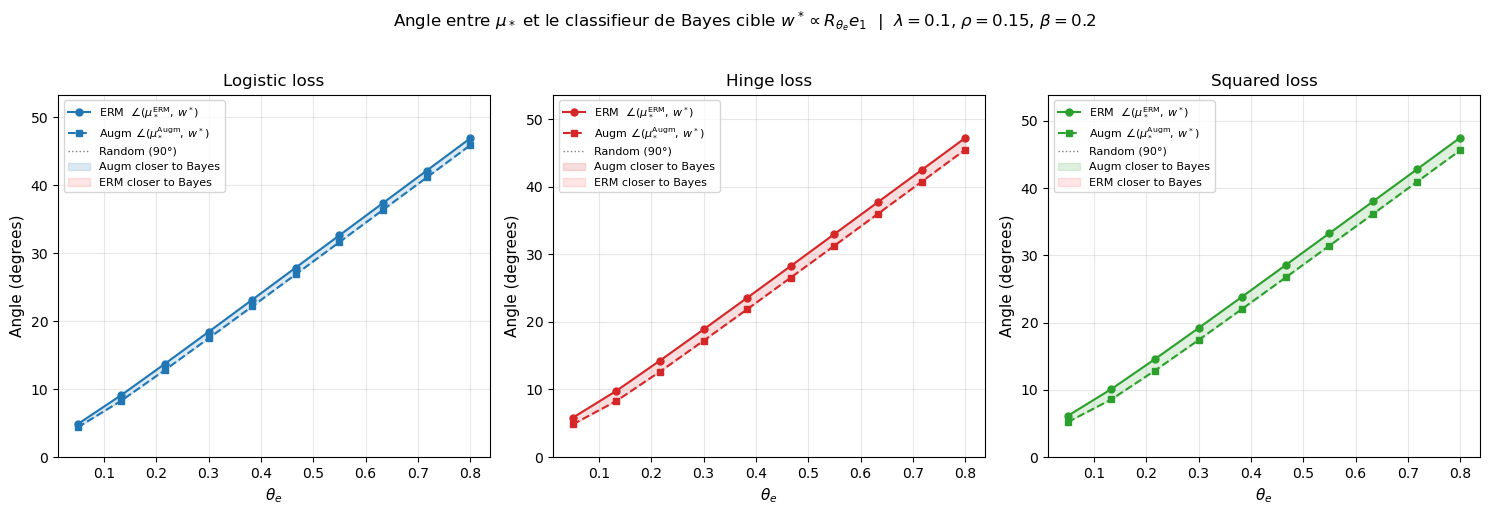

✓ mu* angle analysis done


In [33]:
from scipy.linalg import expm

def bayes_target_direction(p, m, sigma, theta_e):
    """
    Classifieur de Bayes optimal pour le domaine cible.
    w* proportionnel à Sigma^{-1}(mu_1 - mu_0) = (1/sigma^2) * R_{theta_e} * e1
    """
    e1 = e1_vec(p)
    R  = np.eye(p)
    R[0,0] =  np.cos(theta_e); R[0,1] = -np.sin(theta_e)
    R[1,0] =  np.sin(theta_e); R[1,1] =  np.cos(theta_e)
    w = R @ e1 / sigma**2
    return w / np.linalg.norm(w)  # normalisé

def angle_between(u, v):
    """Angle en degrés entre deux vecteurs."""
    cos = np.clip(np.dot(u/np.linalg.norm(u), v/np.linalg.norm(v)), -1, 1)
    return float(np.degrees(np.arccos(cos)))

def get_mu_star(mod_src, loss, reg, n_train, mc_samples=10000):
    """Résout le point fixe et retourne mu_* normalisé."""
    solver = et.TheoryFixedPointSolver(
        model=mod_src, loss=loss, regularizer=reg,
        n_train=n_train, mc_samples=mc_samples,
        rng=np.random.default_rng(0),
    )
    sol = solver.solve(max_iter=300, damping=0.3, tol=1e-6)
    mu = sol['mu']
    return mu / np.linalg.norm(mu), sol['converged']

# ── Sweep theta_e : angle de mu* ERM et Augm vers le Bayes cible ─────────────
theta_e_grid_mu = np.linspace(0.05, 0.8, 10)
rho_augm = RHO_DEFAULT
beta_augm = BETA_DEFAULT

results_angle = {name: {'erm': [], 'augm': [], 'random': []}
                 for name in LOSS_NAMES}

for the in theta_e_grid_mu:
    w_bayes = bayes_target_direction(p, m, sigma, the)

    # Direction aléatoire comme baseline
    rng_ref = np.random.default_rng(42)
    w_rand  = rng_ref.standard_normal(p)
    w_rand /= np.linalg.norm(w_rand)
    angle_rand = angle_between(w_rand, w_bayes)

    # Modèle augmenté effectif
    mod_aug_loc = augmented_source_model(
        p, m, sigma, rho_augm, beta_augm,
        make_tr_fn=make_transform_uniform,
        n_mc=15000, rng=np.random.default_rng(1))

    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        reg = make_reg(p, LAM_DEFAULT)

        # mu* ERM
        mu_erm, conv_erm = get_mu_star(MOD_SRC, loss, reg, n_train)
        angle_erm = angle_between(mu_erm, w_bayes)

        # mu* Augm
        mu_augm, conv_augm = get_mu_star(mod_aug_loc, loss, reg, n_train)
        angle_augm = angle_between(mu_augm, w_bayes)

        results_angle[name]['erm'].append(angle_erm)
        results_angle[name]['augm'].append(angle_augm)
        results_angle[name]['random'].append(angle_rand)

        print(f'theta_e={the:.2f}  {name:<10}  '
              f'angle_ERM={angle_erm:.2f}°  '
              f'angle_Augm={angle_augm:.2f}°  '
              f'conv_erm={conv_erm}  conv_augm={conv_augm}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    r'Angle entre $\mu_*$ et le classifieur de Bayes cible $w^* \propto R_{\theta_e} e_1$  |  '
    f'$\\lambda={LAM_DEFAULT}$, $\\rho={rho_augm}$, $\\beta={beta_augm}$',
    fontsize=12, y=1.02)

for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
    ae = np.array(results_angle[name]['erm'])
    aa = np.array(results_angle[name]['augm'])
    ar = np.array(results_angle[name]['random'])

    ax.plot(theta_e_grid_mu, ae, color=col, ls='-',  marker='o', ms=5,
            label=r'ERM  $\angle(\mu_*^\mathrm{ERM},\, w^*)$')
    ax.plot(theta_e_grid_mu, aa, color=col, ls='--', marker='s', ms=5,
            label=r'Augm $\angle(\mu_*^\mathrm{Augm},\, w^*)$')
    ax.axhline(90, color='gray', ls=':', lw=1, label='Random (90°)')

    # Remplir la zone où Augm est meilleur
    ax.fill_between(theta_e_grid_mu, ae, aa,
                    where=(aa < ae), color=col, alpha=0.15,
                    label='Augm closer to Bayes')
    ax.fill_between(theta_e_grid_mu, ae, aa,
                    where=(aa >= ae), color='red', alpha=0.10,
                    label='ERM closer to Bayes')

    ax.set_xlabel(r'$\theta_e$', fontsize=11)
    ax.set_ylabel('Angle (degrees)', fontsize=11)
    ax.set_title(f'{name} loss', fontsize=12)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([ae, aa])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 1.0)
    ax.set_ylim(max(0, lo-mg), hi+mg)

plt.tight_layout()
plt.show()
print('✓ mu* angle analysis done')

s2=0.5  Logistic    ERM=51.26°  Augm_unif=51.10°  Augm_e2=51.07°
s2=0.5  Hinge       ERM=51.15°  Augm_unif=50.70°  Augm_e2=50.87°
s2=0.5  Squared     ERM=52.05°  Augm_unif=50.82°  Augm_e2=51.03°
s2=1.0  Logistic    ERM=18.42°  Augm_unif=17.46°  Augm_e2=17.40°
s2=1.0  Hinge       ERM=18.89°  Augm_unif=17.21°  Augm_e2=17.34°
s2=1.0  Squared     ERM=19.18°  Augm_unif=17.40°  Augm_e2=17.56°
s2=1.5  Logistic    ERM=8.16°  Augm_unif=8.46°  Augm_e2=8.34°
s2=1.5  Hinge       ERM=8.55°  Augm_unif=8.45°  Augm_e2=8.52°
s2=1.5  Squared     ERM=8.99°  Augm_unif=8.72°  Augm_e2=8.82°
s2=2.0  Logistic    ERM=5.25°  Augm_unif=5.50°  Augm_e2=5.32°
s2=2.0  Hinge       ERM=5.96°  Augm_unif=5.75°  Augm_e2=5.74°
s2=2.0  Squared     ERM=6.91°  Augm_unif=6.09°  Augm_e2=6.10°
s2=3.0  Logistic    ERM=3.68°  Augm_unif=3.84°  Augm_e2=3.59°
s2=3.0  Hinge       ERM=4.72°  Augm_unif=4.45°  Augm_e2=4.33°
s2=3.0  Squared     ERM=97.25°  Augm_unif=4.83°  Augm_e2=4.74°
s2=5.0  Logistic    ERM=3.29°  Augm_unif=3.38°  Aug

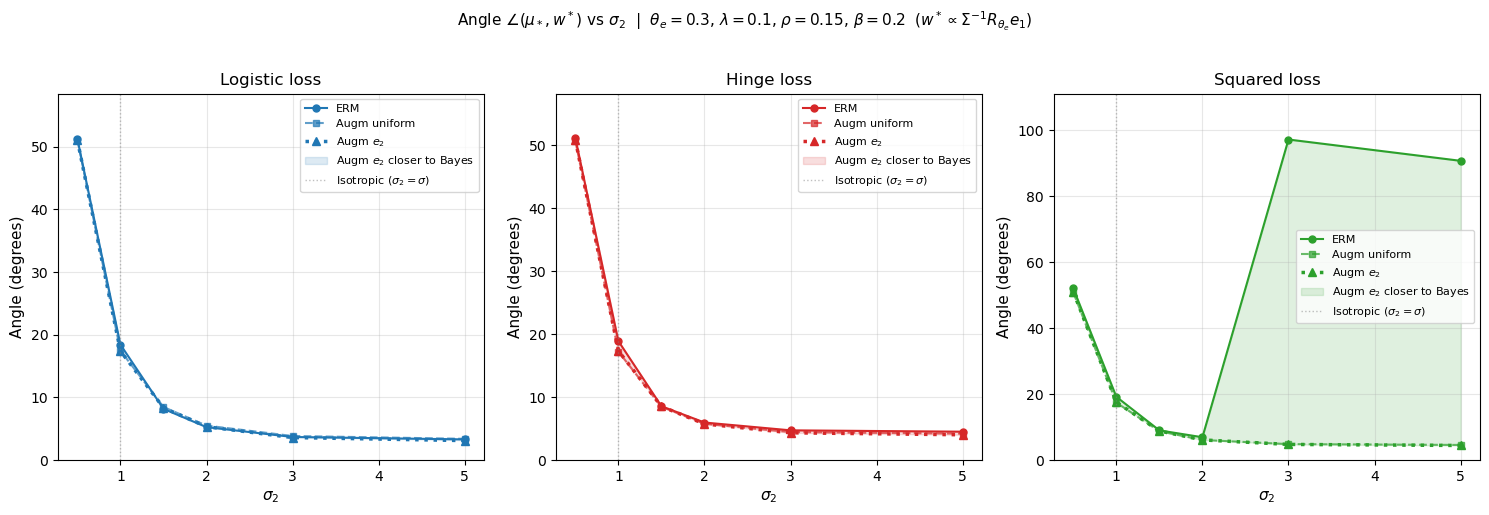

✓ mu* angle vs sigma_2 done


In [34]:
# ── Sweep sigma_2 : angle de mu* ERM et Augm vers le Bayes cible ──────────────
# Dans le modèle anisotrope, w* = Sigma^{-1}(mu_1 - mu_0) / norm
# = Sigma^{-1} * 2m * R_{theta_e} e1 / norm

def bayes_target_direction_aniso(p, m, sigma, sigma2, theta_e):
    """
    Classifieur de Bayes optimal pour modèle anisotrope + rotation cible.
    w* proportionnel à Sigma^{-1} R_{theta_e} e1
    avec Sigma = diag(sigma^2, sigma2^2, sigma^2, ..., sigma^2)
    """
    C_inv = np.diag([1/sigma**2]*p)
    C_inv[1,1] = 1/sigma2**2
    R = np.eye(p)
    R[0,0] =  np.cos(theta_e); R[0,1] = -np.sin(theta_e)
    R[1,0] =  np.sin(theta_e); R[1,1] =  np.cos(theta_e)
    w = C_inv @ R @ e1_vec(p)
    return w / np.linalg.norm(w)

sigma2_grid_mu = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
THETA_E_MU = 0.3   # angle cible fixé

results_angle_s2 = {name: {'erm': [], 'augm_uniform': [], 'augm_e2': []}
                    for name in LOSS_NAMES}

for s2 in sigma2_grid_mu:
    w_bayes = bayes_target_direction_aniso(p, m, sigma, s2, THETA_E_MU)

    mod_src_a  = source_model_aniso(p, m, sigma, s2)

    # Modèle augmenté uniforme
    mod_aug_u = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_uniform,
        n_mc=15000, rng=np.random.default_rng(1))

    # Modèle augmenté structuré e2
    mod_aug_e2 = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_e2,
        n_mc=15000, rng=np.random.default_rng(1))

    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        reg = make_reg(p, LAM_DEFAULT)

        # mu* ERM
        mu_erm,  _ = get_mu_star(mod_src_a,  loss, reg, n_train)
        # mu* Augm uniforme
        mu_au,   _ = get_mu_star(mod_aug_u,  loss, reg, n_train)
        # mu* Augm e2
        mu_ae2,  _ = get_mu_star(mod_aug_e2, loss, reg, n_train)

        results_angle_s2[name]['erm'].append(angle_between(mu_erm, w_bayes))
        results_angle_s2[name]['augm_uniform'].append(angle_between(mu_au,  w_bayes))
        results_angle_s2[name]['augm_e2'].append(angle_between(mu_ae2, w_bayes))

        print(f's2={s2:.1f}  {name:<10}  '
              f'ERM={angle_between(mu_erm, w_bayes):.2f}°  '
              f'Augm_unif={angle_between(mu_au, w_bayes):.2f}°  '
              f'Augm_e2={angle_between(mu_ae2, w_bayes):.2f}°')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    r'Angle $\angle(\mu_*, w^*)$ vs $\sigma_2$  |  '
    f'$\\theta_e={THETA_E_MU}$, $\\lambda={LAM_DEFAULT}$, '
    f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$  '
    r'($w^* \propto \Sigma^{-1} R_{\theta_e} e_1$)',
    fontsize=11, y=1.02)

for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
    ae   = np.array(results_angle_s2[name]['erm'])
    au   = np.array(results_angle_s2[name]['augm_uniform'])
    ae2  = np.array(results_angle_s2[name]['augm_e2'])

    ax.plot(sigma2_grid_mu, ae,  color=col, ls='-',  marker='o', ms=5,
            label='ERM')
    ax.plot(sigma2_grid_mu, au,  color=col, ls='--', marker='s', ms=5,
            alpha=0.7, label='Augm uniform')
    ax.plot(sigma2_grid_mu, ae2, color=col, ls=':',  marker='^', ms=6,
            lw=2.5, label=r'Augm $e_2$')

    # Zone où Augm e2 est meilleur que ERM
    ax.fill_between(sigma2_grid_mu, ae, ae2,
                    where=(ae2 < ae), color=col, alpha=0.15,
                    label=r'Augm $e_2$ closer to Bayes')

    ax.axvline(1.0, color='gray', ls=':', lw=1, alpha=0.5,
               label='Isotropic ($\\sigma_2=\\sigma$)')
    ax.set_xlabel(r'$\sigma_2$', fontsize=11)
    ax.set_ylabel('Angle (degrees)', fontsize=11)
    ax.set_title(f'{name} loss', fontsize=12)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([ae, au, ae2])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 0.5)
    ax.set_ylim(max(0, lo-mg), hi+mg)

plt.tight_layout()
plt.show()
print('✓ mu* angle vs sigma_2 done')

s2=0.5  Logistic    alpha_ERM=0.9419  alpha_unif=0.9695  alpha_e2=0.9547  conv=(False,False,False)
s2=0.5  Hinge       alpha_ERM=1.0823  alpha_unif=1.1077  alpha_e2=1.0984  conv=(False,False,False)
s2=0.5  Squared     alpha_ERM=0.5873  alpha_unif=0.6051  alpha_e2=0.5955  conv=(False,False,False)
s2=1.0  Logistic    alpha_ERM=0.9542  alpha_unif=0.9695  alpha_e2=0.9547  conv=(False,False,False)
s2=1.0  Hinge       alpha_ERM=1.0964  alpha_unif=1.1077  alpha_e2=1.0984  conv=(False,False,False)
s2=1.0  Squared     alpha_ERM=0.5949  alpha_unif=0.6051  alpha_e2=0.5955  conv=(False,False,False)
s2=1.5  Logistic    alpha_ERM=0.9754  alpha_unif=0.9695  alpha_e2=0.9547  conv=(False,False,False)
s2=1.5  Hinge       alpha_ERM=1.1165  alpha_unif=1.1077  alpha_e2=1.0984  conv=(False,False,False)
s2=1.5  Squared     alpha_ERM=0.6005  alpha_unif=0.6051  alpha_e2=0.5955  conv=(False,False,False)
s2=2.0  Logistic    alpha_ERM=0.9870  alpha_unif=0.9695  alpha_e2=0.9547  conv=(False,False,False)
s2=2.0  Hi

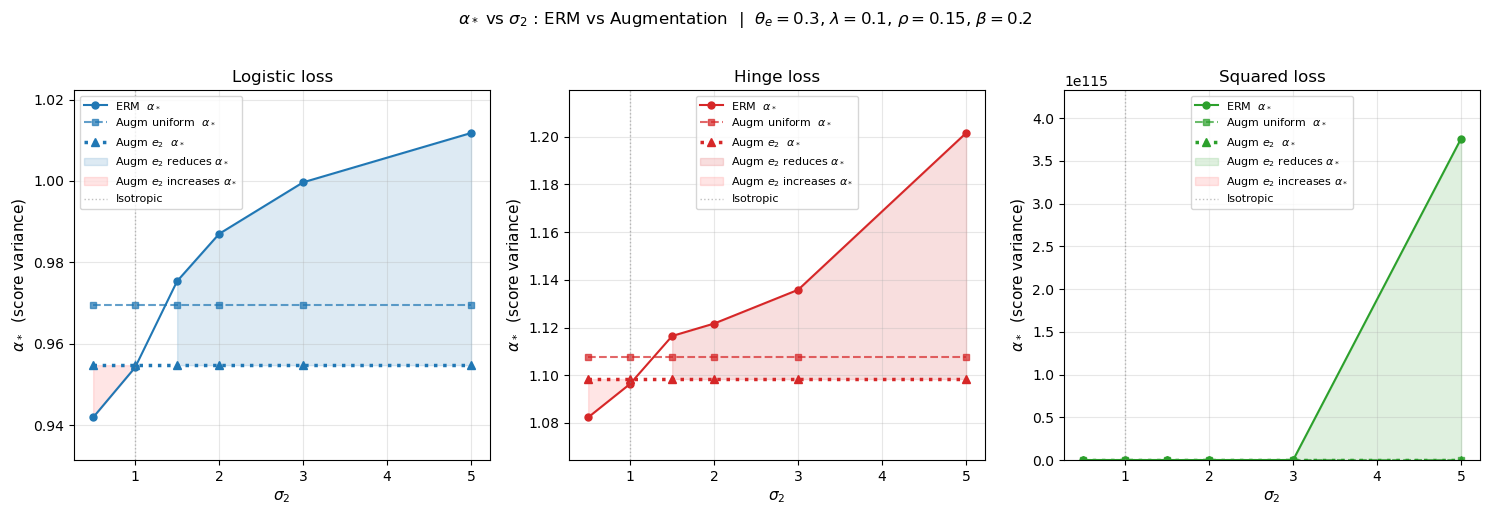

✓ alpha* comparison done


In [35]:
# ── Sweep sigma_2 : comparer alpha* ERM vs Augm ───────────────────────────────

def get_mu_alpha_star(mod_src, loss, reg, n_train, mc_samples=10000):
    """Résout le point fixe et retourne mu_*, alpha_*, et convergence."""
    solver = et.TheoryFixedPointSolver(
        model=mod_src, loss=loss, regularizer=reg,
        n_train=n_train, mc_samples=mc_samples,
        rng=np.random.default_rng(0),
    )
    sol = solver.solve(max_iter=300, damping=0.3, tol=1e-6)
    return sol['mu'], sol['alpha'], sol['converged']

results_alpha = {name: {'erm': [], 'augm_uniform': [], 'augm_e2': []}
                 for name in LOSS_NAMES}

for s2 in sigma2_grid_mu:
    mod_src_a  = source_model_aniso(p, m, sigma, s2)
    mod_aug_u  = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_uniform,
        n_mc=15000, rng=np.random.default_rng(1))
    mod_aug_e2 = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_e2,
        n_mc=15000, rng=np.random.default_rng(1))

    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        reg = make_reg(p, LAM_DEFAULT)

        _, alpha_erm, conv_e = get_mu_alpha_star(mod_src_a,  loss, reg, n_train)
        _, alpha_au,  conv_u = get_mu_alpha_star(mod_aug_u,  loss, reg, n_train)
        _, alpha_ae2, conv_2 = get_mu_alpha_star(mod_aug_e2, loss, reg, n_train)

        # alpha est un vecteur (K,) — on prend la moyenne sur les classes
        results_alpha[name]['erm'].append(float(np.mean(alpha_erm)))
        results_alpha[name]['augm_uniform'].append(float(np.mean(alpha_au)))
        results_alpha[name]['augm_e2'].append(float(np.mean(alpha_ae2)))

        print(f's2={s2:.1f}  {name:<10}  '
              f'alpha_ERM={np.mean(alpha_erm):.4f}  '
              f'alpha_unif={np.mean(alpha_au):.4f}  '
              f'alpha_e2={np.mean(alpha_ae2):.4f}  '
              f'conv=({conv_e},{conv_u},{conv_2})')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    r'$\alpha_*$ vs $\sigma_2$ : ERM vs Augmentation  |  '
    f'$\\theta_e={THETA_E_MU}$, $\\lambda={LAM_DEFAULT}$, '
    f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$',
    fontsize=12, y=1.02)

for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
    ae   = np.array(results_alpha[name]['erm'])
    au   = np.array(results_alpha[name]['augm_uniform'])
    ae2  = np.array(results_alpha[name]['augm_e2'])

    ax.plot(sigma2_grid_mu, ae,  color=col, ls='-',  marker='o', ms=5,
            label=r'ERM  $\alpha_*$')
    ax.plot(sigma2_grid_mu, au,  color=col, ls='--', marker='s', ms=5,
            alpha=0.7, label=r'Augm uniform  $\alpha_*$')
    ax.plot(sigma2_grid_mu, ae2, color=col, ls=':',  marker='^', ms=6,
            lw=2.5, label=r'Augm $e_2$  $\alpha_*$')

    # Zone où Augm e2 réduit alpha* (variance réduite)
    ax.fill_between(sigma2_grid_mu, ae, ae2,
                    where=(ae2 < ae), color=col, alpha=0.15,
                    label=r'Augm $e_2$ reduces $\alpha_*$')
    ax.fill_between(sigma2_grid_mu, ae, ae2,
                    where=(ae2 >= ae), color='red', alpha=0.10,
                    label=r'Augm $e_2$ increases $\alpha_*$')

    ax.axvline(1.0, color='gray', ls=':', lw=1, alpha=0.5,
               label='Isotropic')
    ax.set_xlabel(r'$\sigma_2$', fontsize=11)
    ax.set_ylabel(r'$\alpha_*$  (score variance)', fontsize=11)
    ax.set_title(f'{name} loss', fontsize=12)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([ae, au, ae2])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 0.005)
    ax.set_ylim(max(0, lo-mg), hi+mg)

plt.tight_layout()
plt.show()
print('✓ alpha* comparison done')

Augm det — mu_0 (premiers coords): [-0.8823  0.5141  0.0088  0.01  ]
Augm det — mu_1 (premiers coords): [ 8.6590e-01  1.4922e+00 -1.3000e-03  3.2000e-03]

Expected mu_1 (premiers coords): [0.8776 0.4794 0.     0.    ]
theta_e=0.05 done
theta_e=0.13 done
theta_e=0.22 done
theta_e=0.30 done
theta_e=0.38 done
theta_e=0.47 done
theta_e=0.55 done
theta_e=0.63 done
theta_e=0.72 done
theta_e=0.80 done


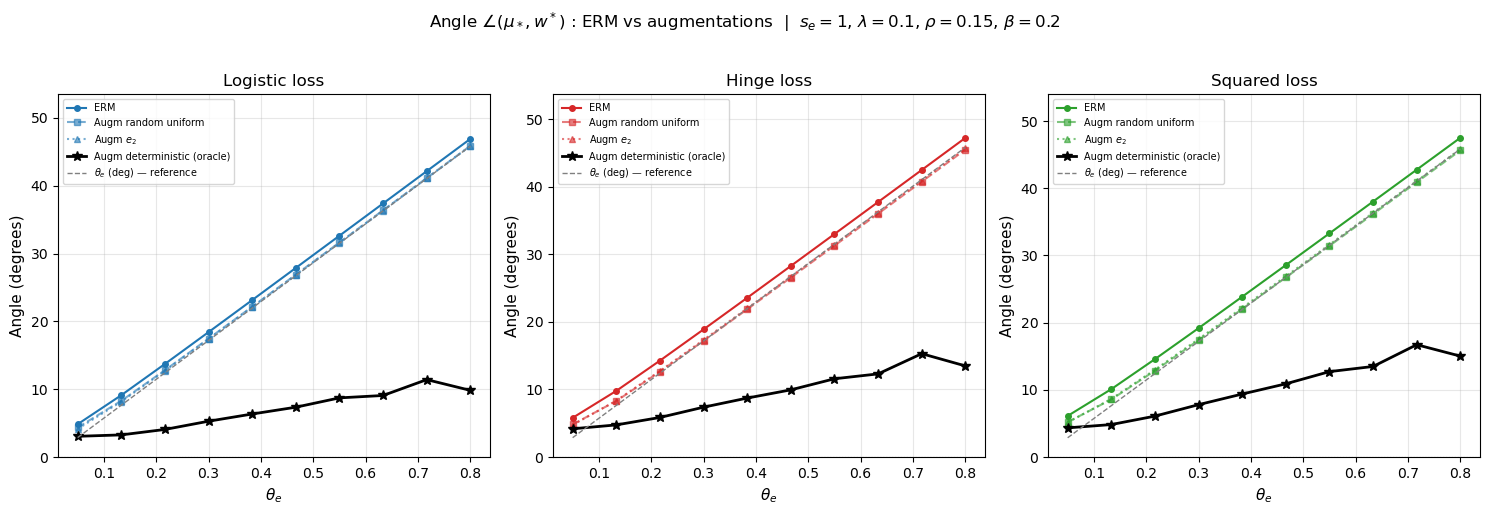

✓ Deterministic augmentation analysis done


In [36]:
def make_transform_deterministic(p, theta_e, s_e):
    """
    Transformation déterministe : rotation exacte R_{theta_e} + shift s_e * e2.
    C'est le cas oracle — on connaît exactement le shift cible.
    """
    R = np.eye(p)
    R[0,0] =  np.cos(theta_e); R[0,1] = -np.sin(theta_e)
    R[1,0] =  np.sin(theta_e); R[1,1] =  np.cos(theta_e)
    b = np.zeros(p); b[1] = s_e

    def transform(X):
        return X @ R.T + b
    return transform

# ── Modèle source augmenté déterministe ──────────────────────────────────────
mod_aug_det = augmented_source_model(
    p, m, sigma, rho=0.0, beta=0.0,   # rho et beta pas utilisés
    make_tr_fn=lambda p, rho, beta, rng: make_transform_deterministic(
        p, THETA_E_FIXED, S_E_FIXED),
    n_mc=20000, rng=np.random.default_rng(42))

# Vérification des moments
params_det = mod_aug_det.class_params()
print('Augm det — mu_0 (premiers coords):',
      np.round(params_det['mus'][0][:4], 4))
print('Augm det — mu_1 (premiers coords):',
      np.round(params_det['mus'][1][:4], 4))
print()

# Attendu : mu_1 = R_{theta_e} * m * e1
R_the = np.eye(p)
R_the[0,0] =  np.cos(THETA_E_FIXED); R_the[0,1] = -np.sin(THETA_E_FIXED)
R_the[1,0] =  np.sin(THETA_E_FIXED); R_the[1,1] =  np.cos(THETA_E_FIXED)
mu_expected = R_the @ (m * e1_vec(p))
print('Expected mu_1 (premiers coords):', np.round(mu_expected[:4], 4))

# ── Sweep theta_e : angle de mu* pour les 4 stratégies ───────────────────────
theta_e_grid_det = np.linspace(0.05, 0.8, 10)

results_det = {name: {
    'erm': [], 'augm_rand': [], 'augm_e2': [], 'augm_det': []
} for name in LOSS_NAMES}

for the in theta_e_grid_det:
    w_bayes = bayes_target_direction(p, m, sigma, the)

    # Modèle augmenté déterministe calibré sur theta_e courant
    mod_aug_det_loc = augmented_source_model(
        p, m, sigma, rho=0.0, beta=0.0,
        make_tr_fn=lambda p, rho, beta, rng, _the=the, _se=S_E_FIXED:
            make_transform_deterministic(p, _the, _se),
        n_mc=20000, rng=np.random.default_rng(42))

    # Modèle augmenté aléatoire uniforme
    mod_aug_rand_loc = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_uniform,
        n_mc=15000, rng=np.random.default_rng(1))

    # Modèle augmenté e2
    mod_aug_e2_loc = augmented_source_model(
        p, m, sigma, RHO_DEFAULT, BETA_DEFAULT,
        make_tr_fn=make_transform_e2,
        n_mc=15000, rng=np.random.default_rng(1))

    for i, (loss, name) in enumerate(zip(make_losses(p), LOSS_NAMES)):
        reg = make_reg(p, LAM_DEFAULT)

        mu_erm,  _ = get_mu_star(MOD_SRC,          loss, reg, n_train)
        mu_rand, _ = get_mu_star(mod_aug_rand_loc,  loss, reg, n_train)
        mu_e2,   _ = get_mu_star(mod_aug_e2_loc,    loss, reg, n_train)
        mu_det,  _ = get_mu_star(mod_aug_det_loc,   loss, reg, n_train)

        results_det[name]['erm'].append(angle_between(mu_erm,  w_bayes))
        results_det[name]['augm_rand'].append(angle_between(mu_rand, w_bayes))
        results_det[name]['augm_e2'].append(angle_between(mu_e2,  w_bayes))
        results_det[name]['augm_det'].append(angle_between(mu_det, w_bayes))

    print(f'theta_e={the:.2f} done')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    r'Angle $\angle(\mu_*, w^*)$ : ERM vs augmentations  |  '
    f'$s_e={S_E_FIXED}$, $\\lambda={LAM_DEFAULT}$, '
    f'$\\rho={RHO_DEFAULT}$, $\\beta={BETA_DEFAULT}$',
    fontsize=12, y=1.02)

for i, (ax, name, col) in enumerate(zip(axes, LOSS_NAMES, LOSS_COLORS)):
    ae   = np.array(results_det[name]['erm'])
    ar   = np.array(results_det[name]['augm_rand'])
    ae2  = np.array(results_det[name]['augm_e2'])
    adet = np.array(results_det[name]['augm_det'])

    # Référence : angle = theta_e (en degrés)
    theta_ref = np.degrees(theta_e_grid_det)

    ax.plot(theta_e_grid_det, ae,   color=col, ls='-',  marker='o', ms=4,
            label='ERM')
    ax.plot(theta_e_grid_det, ar,   color=col, ls='--', marker='s', ms=4,
            alpha=0.6, label='Augm random uniform')
    ax.plot(theta_e_grid_det, ae2,  color=col, ls=':',  marker='^', ms=4,
            alpha=0.6, label=r'Augm $e_2$')
    ax.plot(theta_e_grid_det, adet, color='black', ls='-', marker='*', ms=7,
            lw=2, label='Augm deterministic (oracle)')
    ax.plot(theta_e_grid_det, theta_ref, color='gray', ls='--', lw=1,
            label=r'$\theta_e$ (deg) — reference')
    ax.axhline(0, color='gray', ls=':', lw=0.8)

    ax.set_xlabel(r'$\theta_e$', fontsize=11)
    ax.set_ylabel('Angle (degrees)', fontsize=11)
    ax.set_title(f'{name} loss', fontsize=12)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    all_v = np.concatenate([ae, ar, ae2, adet])
    lo, hi = all_v.min(), all_v.max()
    mg = max((hi-lo)*0.15, 0.5)
    ax.set_ylim(max(0, lo-mg), hi+mg)

plt.tight_layout()
plt.show()
print('✓ Deterministic augmentation analysis done')